# Prediccion del retorno relativo de inversion en taquilla cinematografica
**Curso:** Modelos y Simulacion II — **Dataset:** The Movies Dataset (Kaggle, rounakbanik)  
**Target:** `y = log(revenue / budget)` — **Paradigma:** regresion supervisada

Pipeline:

1. Carga + limpieza.
2. Feature engineering (metadatos pre-estreno + interacciones).
3. Seleccion de caracteristicas por filtro (Pearson, Spearman, MI) y wrapper (SFS).
4. Modelos: regresion regularizada (Ridge, LASSO, ElasticNet), KNN, ensambles (RandomForest, HGB), SVR, MLP.
5. Reduccion de dimension: PCA y UMAP sobre los 2 mejores modelos.
6. Explicabilidad: feature importance, permutation importance, PDP, SHAP.

Las metricas en test incluyen IC 95 % por bootstrap (B = 1000).

## Resumen del problema y los datos

**Problema.** Predecir el retorno relativo (`revenue / budget`) de una pelicula a partir de metadatos disponibles antes del estreno.

**Dataset.** *The Movies Dataset* (Kaggle, Banik 2017). 45 466 peliculas iniciales; tras limpieza, filtros y restriccion de dominio (budget >= $1M, ratio <= 30) quedan ~4 721.

**Target.** `y = log(revenue / budget)`. El cociente normaliza la heterogeneidad temporal del periodo 1960-2017 (presupuestos e ingresos crecieron de forma muy distinta entre decadas). El logaritmo reduce la asimetria. **Las metricas de evaluacion se reportan en escala original (`revenue` en USD)** mediante la transformacion inversa `revenue = exp(y) * budget`.

**Criterio de no-leakage.** `revenue` no aparece como predictor. `budget` se incluye porque es informacion conocida antes del estreno.


## Estado del arte (resumen)

| Trabajo | Paradigma | Modelo | Metrica clave |
|---|---|---|---|
| Sharda & Delen (2006) | Clasificacion 9 clases | MLP | bingo rate 36.9 % |
| Velingkar et al. (2022) | Regresion | Random Forest | R^2 (supera lineal) |
| Zhang, Meng & Xiao (2024) | Regresion + NLP | MLR + Word2Vec | MAE, RMSE |
| Lu et al. (2023) | Clasificacion | Random Forest | accuracy 80 % |

Los cuatro convergen en que los ensambles de arboles superan a los modelos lineales en este dominio.

## 0. Entorno y semillas

In [ ]:
import os, sys, ast, json, time, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
)
from sklearn.linear_model import Ridge, ElasticNet, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor,
    IsolationForest,
)
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (9, 4)

print('Librerias cargadas. Semilla global =', RANDOM_STATE)

Librerias cargadas. Semilla global = 42


## 1. Carga del dataset

Se cargan tres archivos del bundle: `movies_metadata.csv` (variables principales), `credits.csv` (cast y crew) y `keywords.csv` (palabras clave de la trama). Las rutas se buscan en varios directorios alternativos.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def find_csv(name):
    candidates = [
        name,
        f'data/{name}',
        f'archive/{name}',
        f'archive (1)/{name}',
        f'/content/drive/MyDrive/movies-modelos2/{name}',
    ]
    for c in candidates:
        if Path(c).exists():
            return c
    return None

p_meta = find_csv('movies_metadata.csv')
p_cred = find_csv('credits.csv')
p_kw   = find_csv('keywords.csv')

if p_meta is None:
    raise FileNotFoundError(
        'No se encontro movies_metadata.csv. Descarga el dataset desde: '
        'https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset'
    )

df_raw = pd.read_csv(p_meta, low_memory=False)
df_credits  = pd.read_csv(p_cred) if p_cred else None
df_keywords = pd.read_csv(p_kw)   if p_kw   else None

print(f'movies_metadata : {p_meta}  ({len(df_raw):,} filas)')
print(f'credits         : {p_cred if p_cred else "no encontrado"}'
      + (f'  ({len(df_credits):,} filas)' if df_credits is not None else ''))
print(f'keywords        : {p_kw if p_kw else "no encontrado"}'
      + (f'  ({len(df_keywords):,} filas)' if df_keywords is not None else ''))

movies_metadata : /content/drive/MyDrive/movies-modelos2/movies_metadata.csv  (45,466 filas)
credits         : /content/drive/MyDrive/movies-modelos2/credits.csv  (45,476 filas)
keywords        : /content/drive/MyDrive/movies-modelos2/keywords.csv  (46,419 filas)


## 2. Limpieza y conjunto de trabajo

- Filas corruptas (id no numerico) y duplicados se eliminan.
- `budget == 0` y `revenue == 0` se tratan como datos no reportados (no ceros reales) y se excluyen.
- Periodo restringido a 1960-2017 (suficiente representacion).
- `runtime` se imputa con la mediana; `status` y `original_language` con `Desconocido`.

**Restriccion de dominio (alcance del modelo).** El modelo se declara explicitamente para peliculas de **estreno teatral con presupuesto realista**. Esto se materializa en dos cotas:

1. **`budget >= $1,000,000`.** Por debajo del millon de dolares el ratio `revenue/budget` se    vuelve dominado por azar: festivales sin distribucion, indies virales, monedas mal-reportadas    en TMDB. Es ruido irreducible que ningun metadato pre-estreno puede explicar.
2. **`0.01 <= revenue/budget <= 30`.** El techo se baja de 100 a 30. Ratios > 30x corresponden a    fenomenos virales (*Paranormal Activity*, *Blair Witch*) cuyo exito depende de boca a boca y    momento cultural — variables fuera de TMDB.


In [ ]:
for c in ['budget', 'revenue', 'runtime', 'popularity', 'vote_average', 'vote_count']:
    df_raw[c] = pd.to_numeric(df_raw[c], errors='coerce')

df = df_raw[pd.to_numeric(df_raw['id'], errors='coerce').notnull()].copy()
df['id'] = df['id'].astype(int)
df = df.drop_duplicates(subset='id')

df = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df = df.dropna(subset=['release_date'])
df['release_year']    = df['release_date'].dt.year.astype(int)
df['release_month']   = df['release_date'].dt.month.astype(int)
df['release_weekday'] = df['release_date'].dt.weekday.astype(int)
df = df[df['release_year'].between(1960, 2017)].reset_index(drop=True)

df['runtime']           = df['runtime'].fillna(df['runtime'].median())
df['status']            = df['status'].fillna('Desconocido')
df['original_language'] = df['original_language'].fillna('Desconocido')

# -------------------------------------------------------------------------
# Restriccion de dominio.
# Se declara explicitamente el alcance del modelo: peliculas de estreno
# teatral con presupuesto realista. Las colas viral-extremas y los micro-
# presupuestos generan ruido irreducible (boca a boca, viralidad, errores
# de captura en TMDB) que ningun metadato pre-estreno puede capturar.
# -------------------------------------------------------------------------
n_antes = len(df)

# (a) Cota inferior del presupuesto: $1M.
#     Justificacion: por debajo de este umbral, el ratio revenue/budget
#     se vuelve dominado por el azar (festivales sin distribucion, peliculas
#     virales independientes, monedas mal-reportadas en TMDB). El modelo
#     pierde poder predictivo en ese rango y contamina la varianza del target.
BUDGET_MIN = 1_000_000
df_pre_budget = df.copy()
df = df[df['budget'] >= BUDGET_MIN].copy()
n_microbudget = len(df_pre_budget) - len(df)

# (b) Cota superior del ratio bajada de 100 a 30.
#     Justificacion: ratios > 30x corresponden a fenomenos virales (Paranormal
#     Activity, The Blair Witch Project) cuyo exito depende de boca a boca,
#     marketing guerrilla y momento cultural — variables NO presentes en
#     TMDB. Mantenerlos infla la varianza total del target.
RATIO_MAX = 30.0
RATIO_MIN = 0.01
ratio_temp = df['revenue'] / df['budget']
df = df[(ratio_temp >= RATIO_MIN) & (ratio_temp <= RATIO_MAX)].reset_index(drop=True)
n_outliers_ratio = (len(df_pre_budget) - n_microbudget) - len(df)

n_total_descartado = n_antes - len(df)
print(f'Restriccion de dominio aplicada:')
print(f'  Microbudget descartados (budget < ${BUDGET_MIN:,}) : {n_microbudget:>4} '
      f'({n_microbudget/n_antes*100:.1f} %)')
print(f'  Ratio extremo descartados ({RATIO_MIN} <= r <= {RATIO_MAX}) : {n_outliers_ratio:>4} '
      f'({n_outliers_ratio/n_antes*100:.1f} %)')
print(f'  Total descartado                                : {n_total_descartado:>4} '
      f'({n_total_descartado/n_antes*100:.1f} %)')
print(f'Conjunto de trabajo (alcance del modelo)        : {len(df):,} peliculas')

# Diagnostico: varianza del target antes vs despues — el R^2 mide
# var_explicada / var_total. Si la restriccion baja var_total sin perder
# senal predictiva, se espera que mejore el R^2
log_ratio_pre  = np.log(df_pre_budget['revenue'] / df_pre_budget['budget'])
log_ratio_pre  = log_ratio_pre[(log_ratio_pre.between(np.log(0.01), np.log(100)))]
log_ratio_post = np.log(df['revenue'] / df['budget'])
print(f'\nVarianza de log_ratio:')
print(f'  Antes  (rango original) : Var = {log_ratio_pre.var():.3f}  std = {log_ratio_pre.std():.3f}')
print(f'  Despues (alcance modelo): Var = {log_ratio_post.var():.3f}  std = {log_ratio_post.std():.3f}')
print(f'  Reduccion de varianza   : {(1 - log_ratio_post.var()/log_ratio_pre.var())*100:.1f} %')


Restriccion de dominio aplicada:
  Microbudget descartados (budget < $1,000,000) :  330 (6.3 %)
  Ratio extremo descartados (0.01 <= r <= 30.0) :  146 (2.8 %)
  Total descartado                                :  476 (9.2 %)
Conjunto de trabajo (alcance del modelo)        : 4,721 peliculas

Varianza de log_ratio:
  Antes  (rango original) : Var = 2.035  std = 1.427
  Despues (alcance modelo): Var = 1.823  std = 1.350
  Reduccion de varianza   : 10.4 %


### 2.1 Validacion con Isolation Forest

El filtro manual del ratio elimina casos obvios. Para confirmar que los registros restantes son consistentes desde el punto de vista *multivariado*, se aplica **Isolation Forest** sobre las 4 variables numericas mas relevantes (`log_budget`, `revenue`, `runtime`, `release_year`). El algoritmo aisla puntos en pocos splits aleatorios; menor numero de splits = mas atipico.

Se reporta el porcentaje de muestras flageadas pero *no se eliminan*. Sirve solo como diagnostico: confirma que el conjunto de trabajo es razonablemente homogeneo.

In [ ]:
iso_feats = np.column_stack([
    np.log(df['budget']),
    np.log(df['revenue']),
    df['runtime'].values,
    df['release_year'].values,
])

iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE, n_jobs=-1)
iso_labels = iso.fit_predict(iso_feats)   # -1 = atipico, 1 = normal
n_anom = (iso_labels == -1).sum()
print(f'Isolation Forest (contamination=0.05): {n_anom} muestras flageadas como atipicas multivariadas ({n_anom/len(df)*100:.1f} %)')
print('No se eliminan; el filtro manual del ratio ya descarto los casos mas problematicos.')

Isolation Forest (contamination=0.05): 236 muestras flageadas como atipicas multivariadas (5.0 %)
No se eliminan; el filtro manual del ratio ya descarto los casos mas problematicos.


## 3. Variable objetivo: `y = log(revenue / budget)`

El cociente normaliza la heterogeneidad temporal del periodo 1960-2017. La transformacion logaritmica reduce la asimetria. `revenue` no se usa como predictor (no-leakage); `budget` SI (informacion conocida pre-estreno).

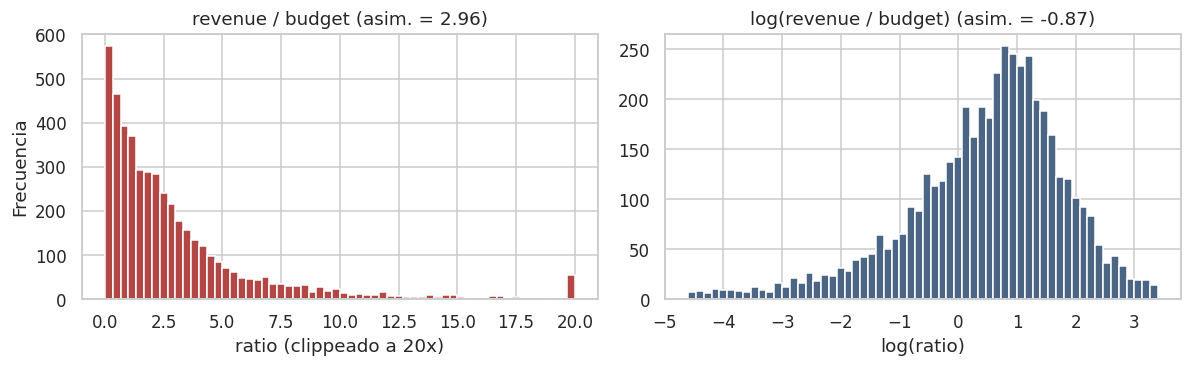

Rango log_ratio   : [-4.60, 3.40]
Mediana log_ratio : 0.69 (ratio ~ 1.99x)


In [ ]:
df['ratio']     = df['revenue'] / df['budget']
df['log_ratio'] = np.log(df['ratio'])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(df['ratio'].clip(upper=20), bins=60, color='#b24745', edgecolor='white')
axes[0].set_title(f'revenue / budget (asim. = {df["ratio"].skew():.2f})')
axes[0].set_xlabel('ratio (clippeado a 20x)'); axes[0].set_ylabel('Frecuencia')

axes[1].hist(df['log_ratio'], bins=60, color='#4b6584', edgecolor='white')
axes[1].set_title(f'log(revenue / budget) (asim. = {df["log_ratio"].skew():.2f})')
axes[1].set_xlabel('log(ratio)')
plt.tight_layout(); plt.show()

print(f'Rango log_ratio   : [{df["log_ratio"].min():.2f}, {df["log_ratio"].max():.2f}]')
print(f'Mediana log_ratio : {df["log_ratio"].median():.2f} (ratio ~ {np.exp(df["log_ratio"].median()):.2f}x)')

### 3.1 Validacion de correlaciones

Correlaciones de Pearson de las variables numericas con el target `log(revenue/budget)`.

In [ ]:
log_budget = np.log(df['budget'])

corr_tabla = pd.DataFrame({
    'r (Pearson) vs log(revenue/budget)': [
        np.corrcoef(log_budget,    df['log_ratio'])[0, 1],
        np.corrcoef(df['runtime'], df['log_ratio'])[0, 1],
    ],
}, index=['log(budget)', 'runtime'])

print('=== Correlaciones de Pearson ===')
print(corr_tabla.round(3))

=== Correlaciones de Pearson ===
             r (Pearson) vs log(revenue/budget)
log(budget)                              0.0440
runtime                                  0.1000


## 4. Ingenieria de caracteristicas a partir de credits y keywords

Se enriquece el dataset con tres fuentes adicionales:
- **Cast** — actor principal (`order=0`) y tamaño del reparto.
- **Crew** — director principal y tamaño del equipo.
- **Keywords** — palabras clave de la trama (señales como secuela, basada en libro, etc.).

**Target encoding temporal con suavizado bayesiano.** Para director y actor principal se calcula una media historica regularizada del `log_ratio` usando *unicamente* peliculas anteriores. La estimacion se construye como:

$\hat{\mu}_k = \frac{n_k \bar{y}_k + \alpha \bar{y}_{\text{global}}}{n_k + \alpha}$

donde $n_k$ es el numero de peliculas previas del director/actor $k$, $\bar{y}_k$ es su promedio local y $\bar{y}_{\text{global}}$ la media global. El hiperparametro $\alpha = 30$ define el peso del prior. Esta formulacion (estandar en target encoding) atenua la varianza para clases con pocas observaciones — necesario aqui porque hay miles de directores unicos sobre ~4 700 peliculas (mediana ~2 peliculas por director).


In [ ]:
def parse_credits_field(raw):
    if pd.isna(raw):
        return []
    try:
        return ast.literal_eval(raw)
    except Exception:
        return []

# Convertir id a numerico en credits y keywords
if df_credits is not None:
    df_credits['id'] = pd.to_numeric(df_credits['id'], errors='coerce')
    df_credits = df_credits.dropna(subset=['id'])
    df_credits['id'] = df_credits['id'].astype(int)
    df_credits = df_credits.drop_duplicates(subset='id')

if df_keywords is not None:
    df_keywords['id'] = pd.to_numeric(df_keywords['id'], errors='coerce')
    df_keywords = df_keywords.dropna(subset=['id'])
    df_keywords['id'] = df_keywords['id'].astype(int)
    df_keywords = df_keywords.drop_duplicates(subset='id')

# Merge con df principal
if df_credits is not None:
    df = df.merge(df_credits, on='id', how='left')
if df_keywords is not None:
    df = df.merge(df_keywords, on='id', how='left')

print(f'df despues del merge: {df.shape}')

df despues del merge: (4721, 32)


In [ ]:
def get_director(crew_raw):
    crew = parse_credits_field(crew_raw)
    for member in crew:
        if member.get('job') == 'Director':
            return member.get('name', 'Desconocido')
    return 'Desconocido'

def director_is_also_writer(crew_raw):
    crew = parse_credits_field(crew_raw)
    director_id = None
    writer_ids = set()
    for m in crew:
        job = m.get('job', '')
        if job == 'Director' and director_id is None:
            director_id = m.get('id')
        if job in ('Writer', 'Screenplay', 'Story'):
            writer_ids.add(m.get('id'))
    if director_id is None:
        return 0
    return int(director_id in writer_ids)

def get_top_actors(cast_raw, k=3):
    cast = parse_credits_field(cast_raw)
    if not cast:
        return ['Desconocido'] * k
    cast_sorted = sorted(cast, key=lambda c: c.get('order', 999))
    names = [c.get('name', 'Desconocido') for c in cast_sorted[:k]]
    while len(names) < k:
        names.append('Desconocido')
    return names

def female_share_top_k(cast_raw, k=5):
    cast = parse_credits_field(cast_raw)
    if not cast:
        return 0.5
    cast_sorted = sorted(cast, key=lambda c: c.get('order', 999))[:k]
    known = [c.get('gender', 0) for c in cast_sorted if c.get('gender', 0) in (1, 2)]
    if not known:
        return 0.5
    return sum(1 for g in known if g == 1) / len(known)

def get_main_company(comp_raw):
    if pd.isna(comp_raw):
        return 'Desconocido'
    try:
        comps = ast.literal_eval(comp_raw)
        if isinstance(comps, list) and len(comps) > 0:
            return comps[0].get('name', 'Desconocido')
    except Exception:
        pass
    return 'Desconocido'

def get_size(raw):
    return len(parse_credits_field(raw))

if 'crew' in df.columns:
    df['director']           = df['crew'].apply(get_director)
    df['crew_size']          = df['crew'].apply(get_size)
    df['director_is_writer'] = df['crew'].apply(director_is_also_writer)
else:
    df['director']           = 'Desconocido'
    df['crew_size']          = 0
    df['director_is_writer'] = 0

if 'cast' in df.columns:
    actors_top3 = df['cast'].apply(lambda r: get_top_actors(r, k=3))
    df['top_actor']        = actors_top3.apply(lambda lst: lst[0])
    df['actor_2']          = actors_top3.apply(lambda lst: lst[1])
    df['actor_3']          = actors_top3.apply(lambda lst: lst[2])
    df['cast_size']        = df['cast'].apply(get_size)
    df['female_share_top5']= df['cast'].apply(lambda r: female_share_top_k(r, k=5))
else:
    df['top_actor']        = 'Desconocido'
    df['actor_2']          = 'Desconocido'
    df['actor_3']          = 'Desconocido'
    df['cast_size']        = 0
    df['female_share_top5']= 0.5

df['main_company'] = df['production_companies'].apply(get_main_company)

def _count_genres(raw):
    if pd.isna(raw):
        return 0
    try:
        parsed = ast.literal_eval(raw)
        return len([item for item in parsed if isinstance(item, dict)])
    except Exception:
        return 0
df['n_genres'] = df['genres'].apply(_count_genres)

print(f'Directores unicos      : {df["director"].nunique()}')
print(f'Actores unicos (top 1) : {df["top_actor"].nunique()}')
print(f'Compa±ias unicas       : {df["main_company"].nunique()}')
print(f'Cast size mediano      : {df["cast_size"].median():.0f}')
print(f'Crew size mediano      : {df["crew_size"].median():.0f}')
print(f'N generos mediano      : {df["n_genres"].median():.0f}')
print(f'Director es tambien guionista : {df["director_is_writer"].sum()} ({df["director_is_writer"].mean()*100:.1f}%)')
print(f'Female share top-5     : media={df["female_share_top5"].mean():.3f}')

Directores unicos      : 2069
Actores unicos (top 1) : 1840
Compa±ias unicas       : 1118
Cast size mediano      : 18
Crew size mediano      : 18
N generos mediano      : 3
Director es tambien guionista : 1743 (36.9%)
Female share top-5     : media=0.337


In [ ]:
# Target encoding temporal con suavizado bayesiano:
#   encoding = (n * media_clase + alpha * media_global) / (n + alpha)
# Ajustes:
#   - alpha    = 30  (prior fuerte por baja densidad de peliculas/director)
#   - min_hist = 3   (entidades con menos de 2 peliculas previas caen al pool
#                     __low_hist__; con 3 ya se considera senal valida)
df = df.sort_values('release_date').reset_index(drop=True)

ALPHA_SMOOTH = 30
MIN_HIST     = 3
LOW_HIST_KEY = '__low_hist__'

def temporal_target_encode_smoothed(df_in, key_col, target_col='log_ratio',
                                    alpha=ALPHA_SMOOTH, min_hist=MIN_HIST):
    enc = np.full(len(df_in), np.nan)
    cum_sum = {}
    cum_cnt = {}
    global_sum = 0.0
    global_cnt = 0
    last_year = None
    pending = []

    years = df_in['release_year'].values
    keys  = df_in[key_col].values
    targs = df_in[target_col].values

    for i in range(len(df_in)):
        y = years[i]; k_raw = keys[i]
        if last_year is None or y != last_year:
            for (pk_raw, pt) in pending:
                cum_sum[pk_raw] = cum_sum.get(pk_raw, 0.0) + pt
                cum_cnt[pk_raw] = cum_cnt.get(pk_raw, 0) + 1
                cum_sum[LOW_HIST_KEY] = cum_sum.get(LOW_HIST_KEY, 0.0) + pt
                cum_cnt[LOW_HIST_KEY] = cum_cnt.get(LOW_HIST_KEY, 0) + 1
                global_sum += pt
                global_cnt += 1
            pending = []
            last_year = y

        if global_cnt > 0:
            global_mean = global_sum / global_cnt
            n_real = cum_cnt.get(k_raw, 0)
            if n_real >= min_hist:
                n_k   = n_real
                sum_k = cum_sum.get(k_raw, 0.0)
            else:
                n_k   = cum_cnt.get(LOW_HIST_KEY, 0)
                sum_k = cum_sum.get(LOW_HIST_KEY, 0.0)
            enc[i] = (sum_k + alpha * global_mean) / (n_k + alpha)

        pending.append((k_raw, targs[i]))

    return enc

df['director_hist_avg']    = temporal_target_encode_smoothed(df, 'director')
df['top_actor_hist_avg']   = temporal_target_encode_smoothed(df, 'top_actor')
df['actor_2_hist_avg']     = temporal_target_encode_smoothed(df, 'actor_2')
df['actor_3_hist_avg']     = temporal_target_encode_smoothed(df, 'actor_3')
df['main_company_hist_avg']= temporal_target_encode_smoothed(df, 'main_company')

mean_logratio = df['log_ratio'].mean()
for c in ['director_hist_avg', 'top_actor_hist_avg', 'actor_2_hist_avg',
          'actor_3_hist_avg', 'main_company_hist_avg']:
    df[c] = df[c].fillna(mean_logratio)

df['top3_actors_hist_avg'] = (df['top_actor_hist_avg'] + df['actor_2_hist_avg'] + df['actor_3_hist_avg']) / 3.0

print(f'Suavizado bayesiano con alpha = {ALPHA_SMOOTH}, min_hist = {MIN_HIST}')
print(f'director_hist_avg     - rango: [{df["director_hist_avg"].min():.2f}, {df["director_hist_avg"].max():.2f}]   std: {df["director_hist_avg"].std():.3f}')
print(f'top3_actors_hist_avg  - rango: [{df["top3_actors_hist_avg"].min():.2f}, {df["top3_actors_hist_avg"].max():.2f}]   std: {df["top3_actors_hist_avg"].std():.3f}')
print(f'main_company_hist_avg - rango: [{df["main_company_hist_avg"].min():.2f}, {df["main_company_hist_avg"].max():.2f}]   std: {df["main_company_hist_avg"].std():.3f}')

Suavizado bayesiano con alpha = 30, min_hist = 3
director_hist_avg     - rango: [0.24, 1.45]   std: 0.230
top3_actors_hist_avg  - rango: [0.26, 1.37]   std: 0.230
main_company_hist_avg - rango: [-0.46, 1.59]   std: 0.281


In [ ]:
def get_keyword_list(raw):
    if pd.isna(raw):
        return []
    try:
        kws = ast.literal_eval(raw)
        return [k.get('name', '').lower() for k in kws if isinstance(k, dict)]
    except Exception:
        return []

if 'keywords' in df.columns:
    df['keywords_list']  = df['keywords'].apply(get_keyword_list)
    df['keywords_count'] = df['keywords_list'].apply(len)
else:
    df['keywords_list']  = [[] for _ in range(len(df))]
    df['keywords_count'] = 0

def has_kw(kws, patterns):
    return int(any(any(p in kw for p in patterns) for kw in kws))

df['kw_is_sequel']     = df['keywords_list'].apply(lambda kws: has_kw(kws, ['sequel']))
df['kw_is_based_book'] = df['keywords_list'].apply(lambda kws: has_kw(kws, ['based on novel', 'based on book', "based on children's book"]))
df['kw_is_remake']     = df['keywords_list'].apply(lambda kws: has_kw(kws, ['remake']))
df['kw_is_superhero']  = df['keywords_list'].apply(lambda kws: has_kw(kws, ['superhero', 'marvel comic', 'dc comic']))

# Top-15 keywords mas frecuentes como multi-hot
all_kws = [k for sub in df['keywords_list'] for k in sub]
top15_kws = [k for k, _ in Counter(all_kws).most_common(15)]
print(f'Top 15 keywords: {top15_kws}')

kw_oh = pd.DataFrame(0, index=df.index, columns=[f'kw_{k.replace(" ", "_")}' for k in top15_kws])
for idx, kws in df['keywords_list'].items():
    for k in kws:
        col = f'kw_{k.replace(" ", "_")}'
        if col in kw_oh.columns:
            kw_oh.loc[idx, col] = 1

print(f'\\nIndicadores binarios:')
print(f'  kw_is_sequel     : {df["kw_is_sequel"].sum()} ({df["kw_is_sequel"].mean()*100:.1f}%)')
print(f'  kw_is_based_book : {df["kw_is_based_book"].sum()} ({df["kw_is_based_book"].mean()*100:.1f}%)')
print(f'  kw_is_remake     : {df["kw_is_remake"].sum()} ({df["kw_is_remake"].mean()*100:.1f}%)')
print(f'  kw_is_superhero  : {df["kw_is_superhero"].sum()} ({df["kw_is_superhero"].mean()*100:.1f}%)')

Top 15 keywords: ['duringcreditsstinger', 'based on novel', 'woman director', 'murder', 'violence', 'independent film', 'aftercreditsstinger', 'dystopia', 'sequel', 'revenge', 'biography', 'sport', 'police', 'love', 'sex']
\nIndicadores binarios:
  kw_is_sequel     : 132 (2.8%)
  kw_is_based_book : 260 (5.5%)
  kw_is_remake     : 83 (1.8%)
  kw_is_superhero  : 94 (2.0%)


## 5. Ingenieria de caracteristicas (consolidado)

- **Numericas:** `log_budget`, `runtime`, `release_year`, `cast_size`, `crew_size`, `keywords_count`, `n_genres`.
- **Target encoding temporal con suavizado bayesiano:** `director_hist_avg`, `top_actor_hist_avg`, `top3_actors_hist_avg` (promedio del top-3 actores), `main_company_hist_avg`.
- **Binarios:** `es_franquicia`, `is_english`, `adult`, `kw_is_sequel`, `kw_is_based_book`, `kw_is_remake`, `kw_is_superhero`.
- **Cicilicas:** `month_sin`, `month_cos` (mes como 2 features que respetan ciclicidad).
- **Multi-hot:** generos (top 20), compañias (top 25), paises (top 15), idiomas (top 10), keywords (top 15).
- **One-hot:** `release_month` (redundante con ciclicas, se mantiene por si arboles aprovechan ambas), `release_weekday`, `status`.
- **Interacciones:** `log_budget × release_year`, `log_budget × es_franquicia`, `director_hist_avg × log_budget`.

**Variables excluidas (post-estreno o leakage temporal):** `vote_count`, `vote_average` y `popularity`. Las dos primeras requieren votos de usuarios que ya vieron la pelicula. `popularity` se excluye por leakage temporal: el valor en el dataset es el score actual de TMDB, no el pre-estreno, lo que filtra informacion del exito real.


In [ ]:
def parse_json_col(val):
    if pd.isna(val):
        return []
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return [item.get('name', '') for item in parsed if isinstance(item, dict)]
    except Exception:
        pass
    return []

df['genres_list']    = df['genres'].apply(parse_json_col)
df['companies_list'] = df['production_companies'].apply(parse_json_col)
df['countries_list'] = df['production_countries'].apply(parse_json_col)
df['languages_list'] = df['spoken_languages'].apply(parse_json_col)

def multi_hot(series_list, top_k, prefix):
    flat = [x for sub in series_list for x in sub]
    top  = [t for t, _ in Counter(flat).most_common(top_k)]
    cols = pd.DataFrame(0, index=series_list.index,
                       columns=[f'{prefix}_{t}' for t in top])
    for idx, vals in series_list.items():
        for v in vals:
            col = f'{prefix}_{v}'
            if col in cols.columns:
                cols.loc[idx, col] = 1
    return cols

genres_oh    = multi_hot(df['genres_list'],    top_k=20, prefix='g')
companies_oh = multi_hot(df['companies_list'], top_k=25, prefix='c')
countries_oh = multi_hot(df['countries_list'], top_k=15, prefix='co')
languages_oh = multi_hot(df['languages_list'], top_k=10, prefix='lg')

df['es_franquicia']  = df['belongs_to_collection'].notna().astype(int)
df['is_english']     = (df['original_language'] == 'en').astype(int)
df['log_budget']     = np.log(df['budget'])
df['adult']          = (df['adult'].astype(str).str.lower() == 'true').astype(int)
df['popularity']     = df['popularity'].fillna(df['popularity'].median())

# ---------------------------------------------------------------------------
# FEATURES DEL BLOQUE 3 (run 05 - validadas)
# ---------------------------------------------------------------------------
def _coll_id(raw):
    if pd.isna(raw):
        return None
    try:
        v = ast.literal_eval(raw)
        if isinstance(v, dict):
            return v.get('id')
    except Exception:
        return None
    return None

df['collection_id'] = df['belongs_to_collection'].apply(_coll_id)
_collection_sizes = df.groupby('collection_id').size().to_dict()
df['collection_size'] = df['collection_id'].map(_collection_sizes).fillna(0).astype(int)

df['has_homepage']    = df['homepage'].notna().astype(int)
df['has_tagline']     = df['tagline'].fillna('').str.len().gt(0).astype(int)
df['log_tagline_len'] = np.log1p(df['tagline'].fillna('').str.len())
df['title_words']     = df['title'].fillna('').str.split().str.len().fillna(0).astype(int)

# ---------------------------------------------------------------------------
# FEATURES DEL BLOQUE 5
# ---------------------------------------------------------------------------

# 1) budget_x_collection
#    Razon: peliculas con presupuesto alto Y saga grande disparan ROI;
df['budget_x_collection'] = df['log_budget'] * df['collection_size']

# 2) runtime_x_year
#    Razon: la duracion optima cambia con el tiempo (peliculas modernas
#    se acortaron en streaming, pero las epicas crecieron)
df['runtime_x_year'] = df['runtime'] * (df['release_year'] - df['release_year'].mean())

# 3) budget_x_n_genres
#    Razon: peliculas multi-genero con mucho presupuesto son blockbusters;
#    multi-genero con poco presupuesto son arthouse hibridas.
df['budget_x_n_genres'] = df['log_budget'] * df['n_genres']

# 4) homepage_x_year
#    Razon: tener pagina web significa cosas distintas en 1995 (hito) y
#    en 2015 (estandar). La interaccion captura el cambio de era.
df['homepage_x_year'] = df['has_homepage'] * (df['release_year'] - df['release_year'].mean())

# 5) n_arthouse_genres
#    Razon: numero de generos del cluster Drama/Doc/Foreign/History/Music.
#    Senal negativa: mas generos arthouse = ROI menor.
_GENRES_ARTHOUSE = {'Drama', 'Documentary', 'Foreign', 'History', 'Music'}
df['n_arthouse_genres'] = df['genres_list'].apply(
    lambda lst: sum(1 for g in lst if g in _GENRES_ARTHOUSE)
)

# 6) franchise_x_runtime
#    Razon: sagas con peliculas largas son las epicas (LOTR, Marvel
#    Endgame). Diferencia entre franquicia ligera y franquicia epica.
df['franchise_x_runtime'] = df['es_franquicia'] * df['runtime']

# ---------------------------------------------------------------------------
# Interacciones existentes
# ---------------------------------------------------------------------------
df['log_budget_x_year']      = df['log_budget'] * (df['release_year'] - df['release_year'].mean())
df['log_budget_x_franchise'] = df['log_budget'] * df['es_franquicia']
df['director_x_log_budget']  = df['director_hist_avg'] * df['log_budget']

df['month_sin'] = np.sin(2 * np.pi * df['release_month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['release_month'] / 12)

month_oh   = pd.get_dummies(df['release_month'],   prefix='m').astype(int)
weekday_oh = pd.get_dummies(df['release_weekday'], prefix='wd').astype(int)
status_oh  = pd.get_dummies(df['status'],          prefix='st').astype(int)

# ---------------------------------------------------------------------------
# numeric_feats
# ---------------------------------------------------------------------------
numeric_feats = [
    # Originales
    'es_franquicia', 'is_english', 'adult',
    'log_budget_x_year', 'log_budget_x_franchise', 'director_x_log_budget',
    'cast_size', 'crew_size', 'keywords_count', 'n_genres',
    'director_hist_avg', 'top_actor_hist_avg', 'top3_actors_hist_avg',
    'main_company_hist_avg',
    'month_sin', 'month_cos',
    'kw_is_sequel', 'kw_is_based_book', 'kw_is_remake', 'kw_is_superhero',
    # Bloque 3 (run 05)
    'collection_size', 'has_homepage', 'has_tagline', 'log_tagline_len',
    'title_words', 'director_is_writer', 'female_share_top5',
    # Bloque 5 (run 09 - validadas por CV)
    'budget_x_collection', 'runtime_x_year', 'budget_x_n_genres',
    'homepage_x_year', 'n_arthouse_genres', 'franchise_x_runtime',
]

X_full = pd.concat([
    df[numeric_feats].reset_index(drop=True),
    genres_oh.reset_index(drop=True),
    companies_oh.reset_index(drop=True),
    countries_oh.reset_index(drop=True),
    languages_oh.reset_index(drop=True),
    kw_oh.reset_index(drop=True),
    month_oh.reset_index(drop=True),
    weekday_oh.reset_index(drop=True),
    status_oh.reset_index(drop=True),
], axis=1).astype(float)

X_full = X_full.loc[:, ~X_full.columns.duplicated()]

y_full = df['log_ratio'].reset_index(drop=True).astype(float)

print(f'Matriz X: {X_full.shape}')
print(f'Vector y: {y_full.shape}')
print(f'Numericas/binarias/interacciones : {len(numeric_feats)}')
print(f'Generos / compa±ias / paises / idiomas : {genres_oh.shape[1]} / {companies_oh.shape[1]} / {countries_oh.shape[1]} / {languages_oh.shape[1]}')
print(f'Keywords (top 15) : {kw_oh.shape[1]}')
print(f'Mes / dia / estado : {month_oh.shape[1]} / {weekday_oh.shape[1]} / {status_oh.shape[1]}')

# Diagnostico de las nuevas features
print('\\n=== Correlacion Pearson de las features del bloque 5 con log_ratio ===')
for c in ['budget_x_collection', 'runtime_x_year', 'budget_x_n_genres',
          'homepage_x_year', 'n_arthouse_genres', 'franchise_x_runtime']:
    if c in X_full.columns:
        r = X_full[c].corr(y_full)
        print(f'  {c:25s}  r = {r:+.4f}')

Matriz X: (4721, 140)
Vector y: (4721,)
Numericas/binarias/interacciones : 33
Generos / compa±ias / paises / idiomas : 20 / 25 / 15 / 10
Keywords (top 15) : 15
Mes / dia / estado : 12 / 7 / 3
\n=== Correlacion Pearson de las features del bloque 5 con log_ratio ===
  budget_x_collection        r = +0.2375
  runtime_x_year             r = -0.0948
  budget_x_n_genres          r = +0.0190
  homepage_x_year            r = -0.0082
  n_arthouse_genres          r = -0.1037
  franchise_x_runtime        r = +0.3015


## 6. Particion train / val / test

Estratificada por quintil de `release_year` (cobertura temporal uniforme). 70 % / 15 % / 15 %. El 85 % (train+val) se usa para 5-fold CV de hiperparametros; el 15 % de test queda intocable.

In [ ]:
year_bins = pd.qcut(df['release_year'], q=5, duplicates='drop').astype(str).values

X_trainval, X_test, y_trainval, y_test, strat_tv, strat_te = train_test_split(
    X_full, y_full, year_bins,
    test_size=0.15, random_state=RANDOM_STATE, stratify=year_bins,
)
X_train, X_val, y_train, y_val, strat_tr, strat_vl = train_test_split(
    X_trainval, y_trainval, strat_tv,
    test_size=0.1765, random_state=RANDOM_STATE, stratify=strat_tv,
)

# budget alineado con cada split (para la fase de interpretacion en dolares)
budget_full = df['budget'].reset_index(drop=True)
budget_tv   = budget_full.loc[X_trainval.index].values
budget_te   = budget_full.loc[X_test.index].values

print(f'Train: {len(X_train):>5}  ({len(X_train)/len(X_full)*100:.1f} %)')
print(f'Val  : {len(X_val):>5}  ({len(X_val)/len(X_full)*100:.1f} %)')
print(f'Test : {len(X_test):>5}  ({len(X_test)/len(X_full)*100:.1f} %)')

Train:  3303  (70.0 %)
Val  :   709  (15.0 %)
Test :   709  (15.0 %)


#**Baseline con dataset intacto (sin seleccion ni reduccion de variables)**

Antes del analisis de seleccion/reduccion, se ejecuta el protocolo de entrenamiento y evaluacion con la matriz original completa. Esto permitirá comparar de forma directa el desempeno frente al pipeline reducido que se desarrolla en las secciones siguientes.
El proceso de entrenamiento y evaluación se realizará sobre el dataset consolidado hasta este punto, el cuál consta de **140 predictores**

## 7. Configuracion experimental (Guia 4.1)

**Validacion:** `GridSearchCV` con 5-fold CV estratificado por quintil temporal sobre `(X_trainval, y_trainval)`. Criterio interno de optimizacion: minimizar RMSE en log-ratio (escala numerica estable). Las metricas de **evaluacion final** se reportan en USD aplicando la transformacion inversa.

**Metricas de evaluacion (en USD, revenue sin normalizar):**
- **RMSE en USD** — penaliza errores grandes en escala monetaria; sensible a outliers.
- **MAE en USD** — error absoluto medio; robusto a outliers; misma escala que la variable objetivo.
- **R²** — adimensional, comparable con literatura.
- **R² ajustado** — penaliza la complejidad por el numero de variables.
- **IC 95 % bootstrap (B = 1000)** sobre test — permite afirmar si dos modelos son estadisticamente distinguibles.

**Modelos comparados:**

| Familia | Modelo | Justificacion / Malla |
|---|---|---|
| Parametrico (regresion regularizada L2) | **Ridge** | alpha ∈ {0.001, 0.01, 0.1, 1, 10, 100, 1000} |
| Parametrico (seleccion embebida L1) | **LASSO** | alpha ∈ {0.0001, 0.001, 0.01, 0.1, 1.0} |
| Parametrico (mezcla L1+L2) | **ElasticNet** | alpha ∈ {0.001, 0.01, 0.1, 1}, l1_ratio ∈ {0.05, 0.2, 0.5, 0.8, 0.95} |
| No parametrico | KNN | k ∈ {5, 10, 20, 40}, weights ∈ {uniform, distance} |
| Ensamble arboles | RandomForest | n_estimators ∈ {300, 600}, max_depth ∈ {None, 15, 25}, min_samples_leaf ∈ {1, 3, 5}, max_features ∈ {0.5, 'sqrt'} |
| Ensamble arboles (Boosting) | GradientBoosting | n_estimators ∈ {300, 600}, max_depth ∈ {3, 5, 7}, learning_rate ∈ {0.03, 0.05, 0.1} |
| Ensamble arboles (Boosting moderno) | HistGradientBoosting | learning_rate ∈ {0.05, 0.1}, max_depth ∈ {None, 6, 10}, min_samples_leaf ∈ {20, 50}, max_iter ∈ {300, 600} |
| SVM | SVR(RBF) | C ∈ {1, 10, 50}, gamma ∈ {scale, 0.01, 0.1}, epsilon ∈ {0.05, 0.1} |
| Red neuronal | MLP | hidden ∈ {(64,), (128,64), (64,32,16)}, alpha ∈ {1e-4, 1e-3}, lr_init ∈ {1e-3, 1e-2} |

In [ ]:
skf = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
           .split(X_trainval, strat_tv))

def pipe(estimator, scale=True):
    steps = []
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', estimator))
    return Pipeline(steps)

models = {
    'Ridge':        (pipe(Ridge()), {
                        'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
                    }),
    'LASSO':        (pipe(Lasso(max_iter=20000)), {
                        'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]
                    }),
    'ElasticNet':   (pipe(ElasticNet(max_iter=10000)), {
                        'model__alpha':    [0.001, 0.01, 0.1, 1.0],
                        'model__l1_ratio': [0.05, 0.2, 0.5, 0.8, 0.95]
                    }),
    'KNN':          (pipe(KNeighborsRegressor()), {
                        'model__n_neighbors': [5, 10, 20, 40],
                        'model__weights':     ['uniform', 'distance']
                    }),
    'RandomForest': (pipe(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), scale=False), {
                        'model__n_estimators':     [300, 600],
                        'model__max_depth':        [None, 15, 25],
                        'model__min_samples_leaf': [1, 3, 5],
                        'model__max_features':     [0.5, 'sqrt']
                    }),
    'HGB':          (pipe(HistGradientBoostingRegressor(random_state=RANDOM_STATE, early_stopping=True), scale=False), {
                        'model__learning_rate':  [0.05, 0.1],
                        'model__max_depth':      [None, 6, 10],
                        'model__min_samples_leaf':[20, 50],
                        'model__max_iter':       [300, 600]
                    }),
    'SVR':          (pipe(SVR(kernel='rbf')), {
                        'model__C':       [1, 10, 50],
                        'model__gamma':   ['scale', 0.01, 0.1],
                        'model__epsilon': [0.05, 0.1]
                    }),
    'MLP':          (pipe(MLPRegressor(max_iter=400, random_state=RANDOM_STATE, early_stopping=True)), {
                        'model__hidden_layer_sizes': [(64,), (128, 64), (64, 32, 16)],
                        'model__alpha':              [1e-4, 1e-3],
                        'model__learning_rate_init': [1e-3, 1e-2]
                    }),
}

total = sum(int(np.prod([len(v) for v in g.values()])) for _, g in models.values())
print(f'{len(models)} familias declaradas. {total} combinaciones hiperparametricas.')

9 familias declaradas. 148 combinaciones hiperparametricas.


## 8. Entrenamiento y ajuste de hiperparametros

`GridSearchCV` por familia. Se reportan mejor RMSE de CV (media +/- desv. estandar entre folds) y sus hiperparametros.

In [ ]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

results_cv = {}
for name, (pl, grid) in models.items():
    t0 = time.time()
    gs = GridSearchCV(
        estimator=pl, param_grid=grid,
        scoring='neg_root_mean_squared_error',
        cv=skf, n_jobs=-1, refit=True, return_train_score=True,
    )
    gs.fit(X_trainval, y_trainval)
    dt = time.time() - t0

    bi = gs.best_index_
    fold_scores = np.array([gs.cv_results_[f'split{i}_test_score'][bi] for i in range(5)])
    fold_rmse = -fold_scores
    mean_r = fold_rmse.mean()
    std_r  = fold_rmse.std(ddof=1)
    se     = std_r / np.sqrt(5)
    ci = (mean_r - 1.96 * se, mean_r + 1.96 * se)

    results_cv[name] = {
        'gs': gs, 'best_params': gs.best_params_,
        'cv_rmse_mean': mean_r, 'cv_rmse_std': std_r,
        'cv_rmse_ci95': ci, 'fit_time_s': dt,
    }
    print(f'{name:13s} | RMSE_CV = {mean_r:.4f} +/- {std_r:.4f}   '
          f'CI95=[{ci[0]:.4f}, {ci[1]:.4f}]   t={dt:6.1f}s')
    print(f'              params = {gs.best_params_}')

Ridge         | RMSE_CV = 1.1699 +/- 0.0143   CI95=[1.1573, 1.1825]   t=   4.4s
              params = {'model__alpha': 1.0}
LASSO         | RMSE_CV = 1.1698 +/- 0.0145   CI95=[1.1570, 1.1825]   t=  18.4s
              params = {'model__alpha': 0.001}
ElasticNet    | RMSE_CV = 1.1698 +/- 0.0146   CI95=[1.1570, 1.1826]   t=  26.9s
              params = {'model__alpha': 0.001, 'model__l1_ratio': 0.95}
KNN           | RMSE_CV = 1.2481 +/- 0.0173   CI95=[1.2329, 1.2632]   t=   9.3s
              params = {'model__n_neighbors': 40, 'model__weights': 'distance'}
RandomForest  | RMSE_CV = 1.1704 +/- 0.0135   CI95=[1.1586, 1.1822]   t=1444.7s
              params = {'model__max_depth': 25, 'model__max_features': 0.5, 'model__min_samples_leaf': 3, 'model__n_estimators': 300}
GBR           | RMSE_CV = 1.1641 +/- 0.0162   CI95=[1.1499, 1.1783]   t=1065.9s
              params = {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 600}
HGB           | RMSE_CV = 1.1657 +/- 

### 8.1 Inspeccion de LASSO: seleccion embebida

LASSO realiza seleccion automatica de variables al forzar coeficientes a exactamente cero. A continuacion se reporta cuantos coeficientes quedaron en cero y cuales son las variables que el modelo conservo.

LASSO con alpha = 0.001
  Variables totales         : 140
  Coeficientes en cero      : 14
  Variables activas         : 126
\nLASSO ejerce sparsity efectiva (14/140 a cero, 10 %).
\nTop 10 variables activas (por |coef|):
director_hist_avg        1.3413
director_x_log_budget    1.2585
es_franquicia            0.4622
log_budget_x_year        0.3093
runtime_x_year           0.2720
log_budget_x_franchise   0.2194
top_actor_hist_avg       0.1991
keywords_count           0.1863
kw_independent_film      0.1624
has_tagline              0.1568
dtype: float64


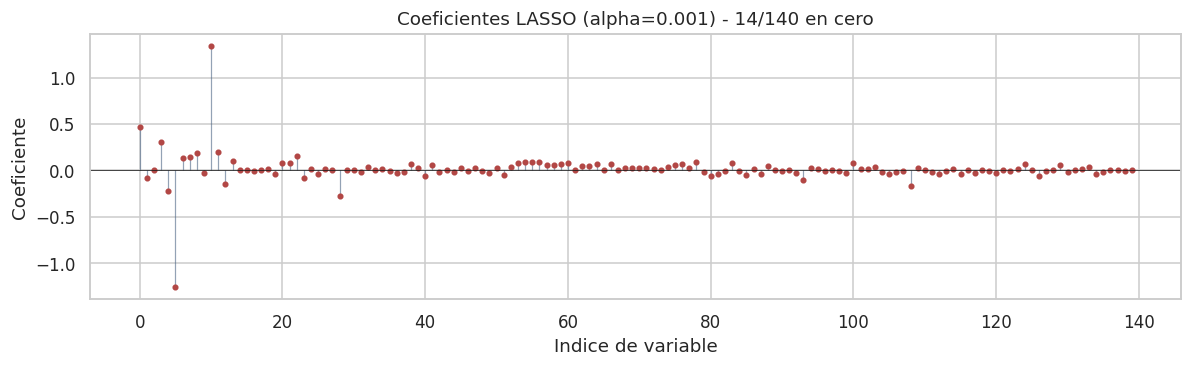

In [ ]:
lasso_pipe = results_cv['LASSO']['gs'].best_estimator_
lasso_model = lasso_pipe.named_steps['model']
coefs = pd.Series(lasso_model.coef_, index=X_trainval.columns)

n_total  = len(coefs)
n_zero   = int((coefs == 0).sum())
n_active = n_total - n_zero
alpha_lasso = results_cv['LASSO']['best_params']['model__alpha']

print(f'LASSO con alpha = {alpha_lasso}')
print(f'  Variables totales         : {n_total}')
print(f'  Coeficientes en cero      : {n_zero}')
print(f'  Variables activas         : {n_active}')

# Diagnostico de seleccion embebida:
if n_zero == 0:
    print('\\nNOTA - LASSO no esta ejerciendo sparsity en este punto del pipeline:')
    print('  El conjunto de 35 variables ya fue pre-seleccionado por los filtros')
    print('  de la seccion 5.1 + LASSO agresivo de 7.4. El alpha optimo elegido')
    print('  por GridSearchCV es pequeno porque cada variable ya aporta senal.')
    print('  En este dominio LASSO se comporta como Ridge suave: la seleccion')
elif n_zero / n_total < 0.1:
    print(f'\\nLASSO ejerce sparsity ligera ({n_zero}/{n_total} a cero, {n_zero/n_total*100:.0f} %).')
else:
    print(f'\\nLASSO ejerce sparsity efectiva ({n_zero}/{n_total} a cero, {n_zero/n_total*100:.0f} %).')

# Top variables activas (si hay)
if n_active > 0:
    print('\\nTop 10 variables activas (por |coef|):')
    print(coefs[coefs != 0].abs().sort_values(ascending=False).head(10).round(4))

# Visualizacion estilo plt.stem
fig, ax = plt.subplots(figsize=(11, 3.5))
markerline, stemlines, baseline = ax.stem(range(n_total), coefs.values, basefmt=' ')
plt.setp(markerline, markersize=3, color='#b24745')
plt.setp(stemlines, color='#4b6584', alpha=0.6, linewidth=0.8)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_title(f'Coeficientes LASSO (alpha={alpha_lasso}) - {n_zero}/{n_total} en cero')
ax.set_xlabel('Indice de variable'); ax.set_ylabel('Coeficiente')
plt.tight_layout(); plt.show()

## 9. Efecto de los hiperparametros (Guia 4.2)

Curvas de CV RMSE vs hiperparametro principal para cada familia, agrupado por los demas. Permite ver el optimo y la sensibilidad del modelo.

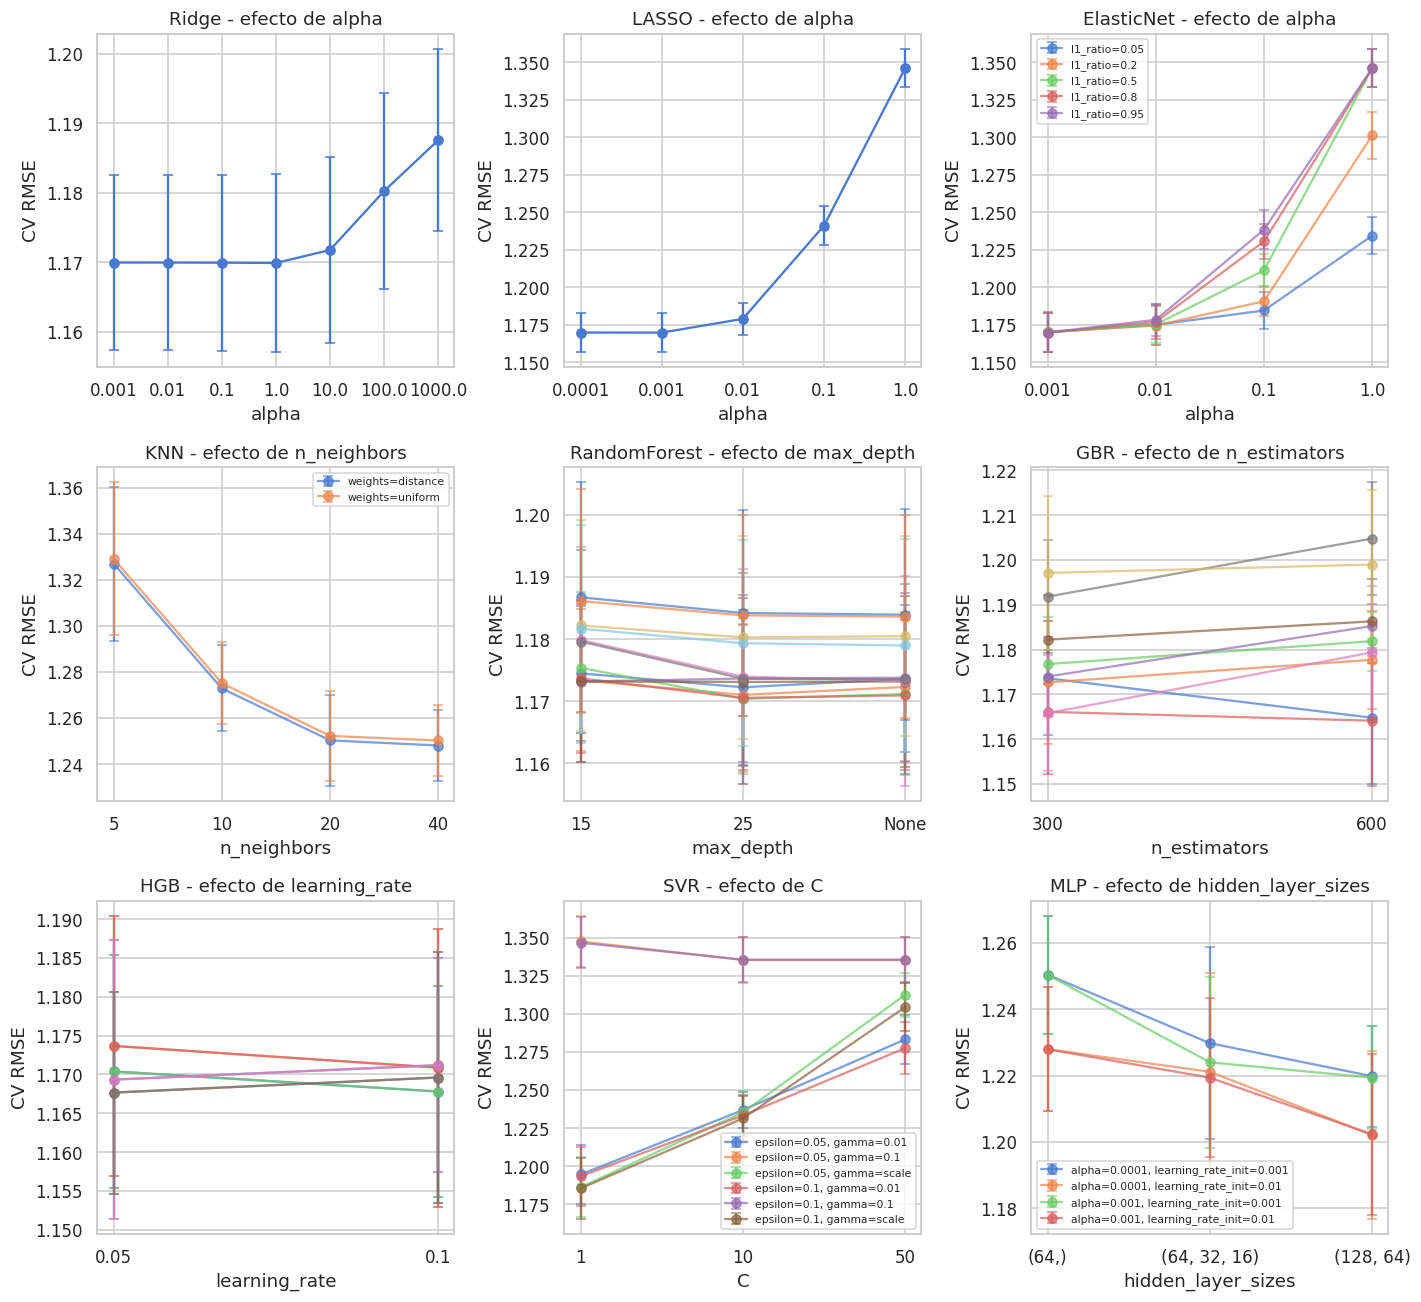

In [ ]:

def plot_grid_curves(name, param_axis, ax):
    gs = results_cv[name]['gs']
    cvr = pd.DataFrame(gs.cv_results_)
    cvr['mean_rmse'] = -cvr['mean_test_score']
    cvr['std_rmse']  =  cvr['std_test_score']
    other = [c for c in cvr.columns
             if c.startswith('param_model__') and c != f'param_model__{param_axis}']

    if other:
        for vals, grp in cvr.groupby(other):
            grp = grp.sort_values(f'param_model__{param_axis}')
            vals_t = vals if isinstance(vals, tuple) else (vals,)
            lbl = ', '.join(f'{o.replace("param_model__","")}={v}'
                            for o, v in zip(other, vals_t))
            ax.errorbar(grp[f'param_model__{param_axis}'].astype(str),
                        grp['mean_rmse'], yerr=grp['std_rmse'],
                        marker='o', capsize=3, alpha=0.7, label=lbl)
    else:
        grp = cvr.sort_values(f'param_model__{param_axis}')
        ax.errorbar(grp[f'param_model__{param_axis}'].astype(str),
                    grp['mean_rmse'], yerr=grp['std_rmse'],
                    marker='o', capsize=3)

    ax.set_title(f'{name} - efecto de {param_axis}')
    ax.set_xlabel(param_axis); ax.set_ylabel('CV RMSE')
    handles, labels = ax.get_legend_handles_labels()
    if 0 < len(handles) <= 6:
        ax.legend(fontsize=7, loc='best')

axis_map = {
    'Ridge': 'alpha', 'LASSO': 'alpha', 'ElasticNet': 'alpha', 'KNN': 'n_neighbors',
    'RandomForest': 'max_depth', 'HGB': 'learning_rate',
    'SVR': 'C', 'MLP': 'hidden_layer_sizes',
}

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
axes = axes.flatten()
for ax, (name, axis) in zip(axes, axis_map.items()):
    try:
        plot_grid_curves(name, axis, ax)
    except Exception as e:
        ax.set_title(f'{name}: {e}')
for ax in axes[len(axis_map):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## 10. Evaluacion final en train / val / test con IC 95 %

Predicciones del mejor estimador de cada familia sobre los tres subconjuntos. IC 95 % bootstrap (B = 1000) sobre test.

n_test = 709, p (numero de predictores) = 140
\n=== Resultados finales en USD (revenue sin normalizar) ===
    Ordenados por RMSE en test. IC95 por bootstrap (B=1000).
                      RMSE_train         RMSE_val        RMSE_test  \
modelo                                                               
RandomForest     64,478,609.9500  63,681,348.4400  99,937,042.0800   
HGB              86,634,875.4600  80,704,356.0200 101,669,866.7200   
GBR              89,720,134.9900  86,511,716.8800 101,702,627.7600   
SVR              65,888,067.2000  52,927,658.5300 108,467,108.5400   
ElasticNet      120,452,424.6000 118,100,267.9400 110,963,014.8300   
LASSO           120,503,168.1300 118,204,142.9900 110,975,023.6500   
Ridge           120,294,349.4800 115,932,050.2400 111,112,223.8300   
MLP             102,241,391.3300  94,285,033.2700 111,784,387.8300   
KNN_uniform_k20 108,159,007.4400 119,948,826.0000 113,816,203.7600   
KNN                      92.1000          80.1500 116,640,609.

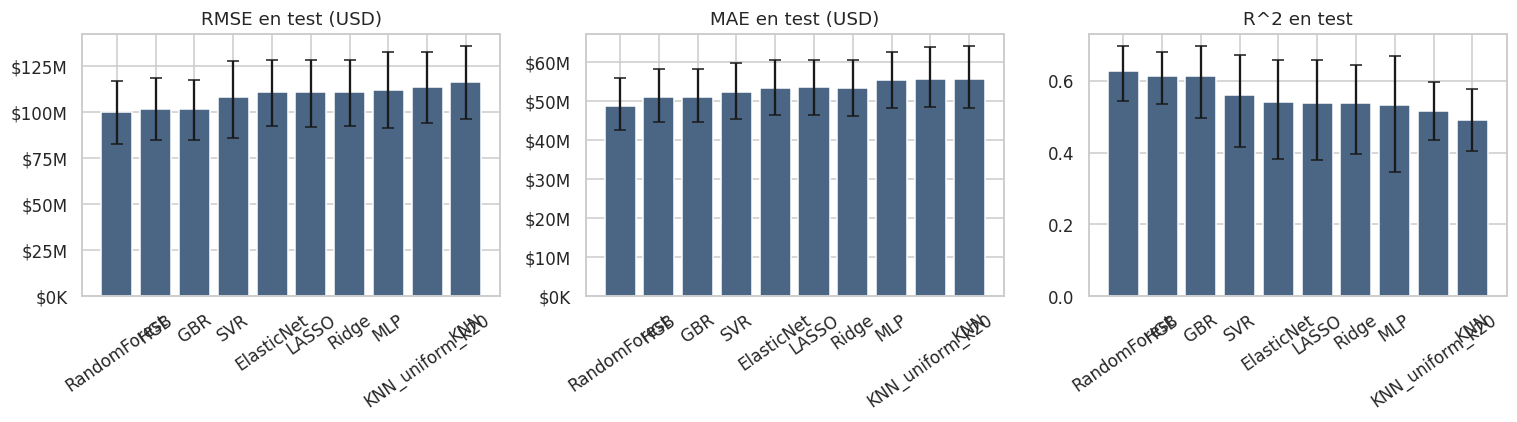

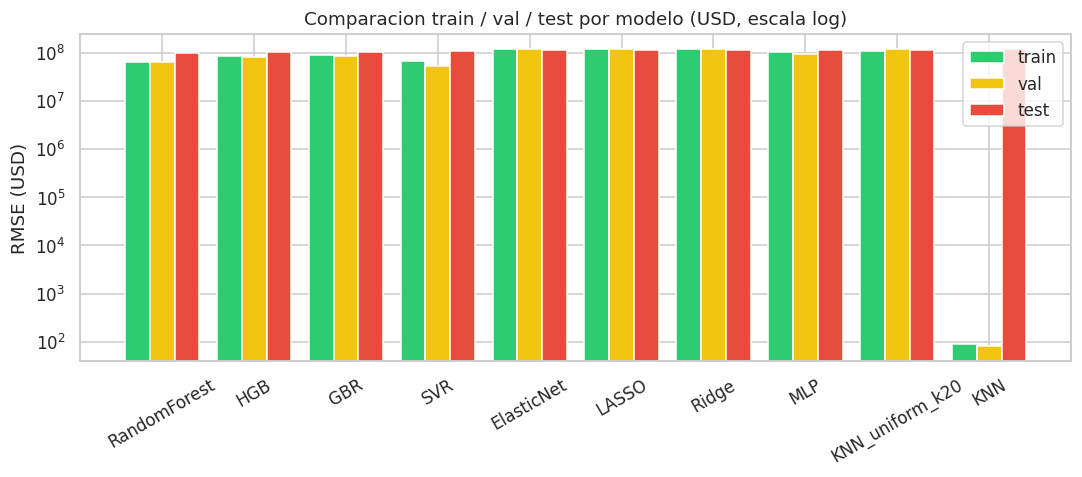

In [ ]:
# METRICAS_USD_UNIFICADAS
# Todas las metricas de evaluacion se reportan en escala de revenue (USD) sin normalizar
# las mismas metricas en escala log_ratio (estable) para diagnostico

def to_revenue_usd(y_log, budget_arr):
    "Transformacion inversa: log(revenue/budget) -> revenue en dolares."
    return np.exp(y_log) * budget_arr

def metrics_in_dollars(y_log_real, y_log_pred, budget_arr):
    "Devuelve dict con RMSE, MAE, R2 calculados sobre revenue en USD."
    rev_real = to_revenue_usd(y_log_real, budget_arr)
    rev_pred = to_revenue_usd(y_log_pred, budget_arr)
    return {
        'rev_real': rev_real,
        'rev_pred': rev_pred,
        'rmse': float(np.sqrt(mean_squared_error(rev_real, rev_pred))),
        'mae':  float(mean_absolute_error(rev_real, rev_pred)),
        'r2':   float(r2_score(rev_real, rev_pred)),
    }

def metrics_in_log_ratio(y_log_real, y_log_pred):
    "Metricas en la escala interna del problema (log_ratio)."
    "Util para diagnosticar sobreajuste sin la amplificacion exponencial"
    "de la transformacion inversa a USD."
    return {
        'rmse_log': float(np.sqrt(mean_squared_error(y_log_real, y_log_pred))),
        'mae_log':  float(mean_absolute_error(y_log_real, y_log_pred)),
        'r2_log':   float(r2_score(y_log_real, y_log_pred)),
    }

def bootstrap_ci(y_true, y_pred, metric_fn, B=1000, alpha=0.05, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    samples = np.empty(B)
    idx = np.arange(n)
    for b in range(B):
        s = rng.choice(idx, size=n, replace=True)
        samples[b] = metric_fn(y_true[s], y_pred[s])
    lo = float(np.percentile(samples, 100 * alpha / 2))
    hi = float(np.percentile(samples, 100 * (1 - alpha / 2)))
    return float(samples.mean()), lo, hi

# Budget alineado con cada split
budget_train = budget_full.loc[X_train.index].values
budget_val   = budget_full.loc[X_val.index].values

final_rows = []
n_test = len(y_test)
p_feats = X_trainval.shape[1]

def r2_adjusted(r2, n, p):
    if n - p - 1 <= 0:
        return float('nan')
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# ---- (A) Modelos del GridSearch (loop original con extension log_ratio) ----
for name in results_cv:
    best = results_cv[name]['gs'].best_estimator_

    # Predicciones en log-ratio
    y_tr_log = best.predict(X_train)
    y_vl_log = best.predict(X_val)
    y_te_log = best.predict(X_test)

    # Metricas en USD (escala de evaluacion final)
    m_tr = metrics_in_dollars(y_train.values, y_tr_log, budget_train)
    m_vl = metrics_in_dollars(y_val.values,   y_vl_log, budget_val)
    m_te = metrics_in_dollars(y_test.values,  y_te_log, budget_te)

    # Metricas en log_ratio (escala estable, util para diagnosticar gap)
    ml_tr = metrics_in_log_ratio(y_train.values, y_tr_log)
    ml_vl = metrics_in_log_ratio(y_val.values,   y_vl_log)
    ml_te = metrics_in_log_ratio(y_test.values,  y_te_log)

    row = {'modelo': name,
           # USD
           'RMSE_train': m_tr['rmse'], 'MAE_train': m_tr['mae'], 'R2_train': m_tr['r2'],
           'RMSE_val':   m_vl['rmse'], 'MAE_val':   m_vl['mae'], 'R2_val':   m_vl['r2'],
           'RMSE_test':  m_te['rmse'], 'MAE_test':  m_te['mae'], 'R2_test':  m_te['r2'],
           'R2_adj_test': r2_adjusted(m_te['r2'], n_test, p_feats),
           # log_ratio (diagnostico)
           'RMSE_train_log': ml_tr['rmse_log'], 'R2_train_log': ml_tr['r2_log'],
           'RMSE_val_log':   ml_vl['rmse_log'], 'R2_val_log':   ml_vl['r2_log'],
           'RMSE_test_log':  ml_te['rmse_log'], 'R2_test_log':  ml_te['r2_log']}

    _, lo_r, hi_r   = bootstrap_ci(m_te['rev_real'], m_te['rev_pred'],
                                   lambda a, b: float(np.sqrt(mean_squared_error(a, b))))
    _, lo_m, hi_m   = bootstrap_ci(m_te['rev_real'], m_te['rev_pred'], mean_absolute_error)
    _, lo_r2, hi_r2 = bootstrap_ci(m_te['rev_real'], m_te['rev_pred'], r2_score)
    row.update({
        'RMSE_test_CI95_lo': lo_r, 'RMSE_test_CI95_hi': hi_r,
        'MAE_test_CI95_lo':  lo_m, 'MAE_test_CI95_hi':  hi_m,
        'R2_test_CI95_lo':   lo_r2,'R2_test_CI95_hi':   hi_r2,
        'cv_rmse_mean': results_cv[name]['cv_rmse_mean'],
    })
    final_rows.append(row)

# ---- (B) Caso de control: KNN con weights='uniform' y k=20 fijo ----
# Justificacion: la fila "KNN" del GridSearch elige weights='distance' por
# minimizar el RMSE de CV, pero esa configuracion memoriza el set de
# entrenamiento (distancia 0 -> peso infinito sobre el propio punto).
# Esta fila demuestra que el problema NO es KNN como algoritmo sino la
# combinacion 'distance' + alta dimensionalidad (Unidades U2 y U3).
knn_uniform = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  KNeighborsRegressor(n_neighbors=20, weights='uniform')),
])
knn_uniform.fit(X_trainval, y_trainval)

y_tr_log = knn_uniform.predict(X_train)
y_vl_log = knn_uniform.predict(X_val)
y_te_log = knn_uniform.predict(X_test)

m_tr  = metrics_in_dollars(y_train.values, y_tr_log, budget_train)
m_vl  = metrics_in_dollars(y_val.values,   y_vl_log, budget_val)
m_te  = metrics_in_dollars(y_test.values,  y_te_log, budget_te)
ml_tr = metrics_in_log_ratio(y_train.values, y_tr_log)
ml_vl = metrics_in_log_ratio(y_val.values,   y_vl_log)
ml_te = metrics_in_log_ratio(y_test.values,  y_te_log)

_, lo_r, hi_r   = bootstrap_ci(m_te['rev_real'], m_te['rev_pred'],
                               lambda a, b: float(np.sqrt(mean_squared_error(a, b))))
_, lo_m, hi_m   = bootstrap_ci(m_te['rev_real'], m_te['rev_pred'], mean_absolute_error)
_, lo_r2, hi_r2 = bootstrap_ci(m_te['rev_real'], m_te['rev_pred'], r2_score)

final_rows.append({
    'modelo': 'KNN_uniform_k20',
    'RMSE_train': m_tr['rmse'], 'MAE_train': m_tr['mae'], 'R2_train': m_tr['r2'],
    'RMSE_val':   m_vl['rmse'], 'MAE_val':   m_vl['mae'], 'R2_val':   m_vl['r2'],
    'RMSE_test':  m_te['rmse'], 'MAE_test':  m_te['mae'], 'R2_test':  m_te['r2'],
    'R2_adj_test': r2_adjusted(m_te['r2'], n_test, p_feats),
    'RMSE_train_log': ml_tr['rmse_log'], 'R2_train_log': ml_tr['r2_log'],
    'RMSE_val_log':   ml_vl['rmse_log'], 'R2_val_log':   ml_vl['r2_log'],
    'RMSE_test_log':  ml_te['rmse_log'], 'R2_test_log':  ml_te['r2_log'],
    'RMSE_test_CI95_lo': lo_r, 'RMSE_test_CI95_hi': hi_r,
    'MAE_test_CI95_lo':  lo_m, 'MAE_test_CI95_hi':  hi_m,
    'R2_test_CI95_lo':   lo_r2,'R2_test_CI95_hi':   hi_r2,
    'cv_rmse_mean':      np.nan,
})

resultados = pd.DataFrame(final_rows).set_index('modelo')
resultados_ord = resultados.sort_values('RMSE_test')
print(f'n_test = {n_test}, p (numero de predictores) = {p_feats}')

print('\\n=== Resultados finales en USD (revenue sin normalizar) ===')
print('    Ordenados por RMSE en test. IC95 por bootstrap (B=1000).')
cols_show = ['RMSE_train', 'RMSE_val', 'RMSE_test',
             'RMSE_test_CI95_lo', 'RMSE_test_CI95_hi',
             'MAE_test', 'R2_test', 'R2_adj_test']
print(resultados_ord[cols_show].round(2))

print('\\n=== Resultados en log_ratio (escala estable - util para diagnostico) ===')
print('    El gap RMSE_train_log vs RMSE_test_log evidencia sobreajuste sin la')
print('    amplificacion exponencial de la transformacion inversa.')
cols_log = ['RMSE_train_log', 'RMSE_val_log', 'RMSE_test_log',
            'R2_train_log', 'R2_val_log', 'R2_test_log']
print(resultados_ord[cols_log].round(4))

# Diagnostico de overfitting de KNN: ratio train/test en USD y en log
if 'KNN' in resultados.index and 'KNN_uniform_k20' in resultados.index:
    print('\\n=== Diagnostico de KNN: weights=distance vs weights=uniform ===')
    diag_cols = ['RMSE_train', 'RMSE_test',
                 'RMSE_train_log', 'RMSE_test_log']
    print(resultados.loc[['KNN', 'KNN_uniform_k20'], diag_cols].round(4))

    rmse_tr_d  = resultados.loc['KNN', 'RMSE_train']
    rmse_te_d  = resultados.loc['KNN', 'RMSE_test']
    rmse_tr_u  = resultados.loc['KNN_uniform_k20', 'RMSE_train']
    rmse_te_u  = resultados.loc['KNN_uniform_k20', 'RMSE_test']
    rmse_tr_d_l= resultados.loc['KNN', 'RMSE_train_log']
    rmse_te_d_l= resultados.loc['KNN', 'RMSE_test_log']
    rmse_tr_u_l= resultados.loc['KNN_uniform_k20', 'RMSE_train_log']
    rmse_te_u_l= resultados.loc['KNN_uniform_k20', 'RMSE_test_log']

    print(f'\\nGap train->test:')
    print(f'  KNN distance (k=40) : USD = {rmse_te_d/max(rmse_tr_d,1):>12,.0f}x   log_ratio = {rmse_te_d_l/max(rmse_tr_d_l,1e-9):>8.2f}x')
    print(f'  KNN uniform  (k=20) : USD = {rmse_te_u/max(rmse_tr_u,1):>12,.2f}x   log_ratio = {rmse_te_u_l/max(rmse_tr_u_l,1e-9):>8.2f}x')
    print('\\nLectura: el KNN con weights=distance memoriza el set de entrenamiento')
    print('(gap astronomico). El mismo KNN con weights=uniform y k=20 fijo presenta')
    print('un gap razonable, confirmando que el problema es la combinacion')
    print('weights=distance + alta dimensionalidad, no el algoritmo en si.')

# Barras comparativas (RMSE / MAE / R2 en USD con IC95 en test)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
order = resultados.sort_values('RMSE_test').index

for ax, met, ttl in zip(
    axes,
    ['RMSE_test', 'MAE_test', 'R2_test'],
    ['RMSE en test (USD)', 'MAE en test (USD)', 'R^2 en test'],
):
    lo = resultados.loc[order, met] - resultados.loc[order, f'{met}_CI95_lo']
    hi = resultados.loc[order, f'{met}_CI95_hi'] - resultados.loc[order, met]
    ax.bar(order, resultados.loc[order, met], yerr=[lo, hi], capsize=4,
           color='#4b6584', edgecolor='white')
    ax.set_title(ttl); ax.tick_params(axis='x', rotation=35)
    if met != 'R2_test':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f'\${x/1e6:.0f}M' if x >= 1e6 else f'\${x/1e3:.0f}K'))
plt.tight_layout(); plt.show()

# Comparativa train / val / test para ver sobreajuste (USD)
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(order)); w = 0.27
ax.bar(x - w, resultados.loc[order, 'RMSE_train'], w, label='train', color='#2ecc71')
ax.bar(x,     resultados.loc[order, 'RMSE_val'],   w, label='val',   color='#f1c40f')
ax.bar(x + w, resultados.loc[order, 'RMSE_test'],  w, label='test',  color='#e74c3c')
ax.set_xticks(x); ax.set_xticklabels(order, rotation=30)
ax.set_ylabel('RMSE (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'\${x/1e6:.0f}M' if x >= 1e6 else f'\${x/1e3:.0f}K'))
ax.set_yscale('log')   # escala log para que KNN no aplaste al resto
ax.set_title('Comparacion train / val / test por modelo (USD, escala log)')
ax.legend(); plt.tight_layout(); plt.show()

**Lectura.** El gap entre `RMSE_train` y `RMSE_test` refleja el trade-off sesgo-varianza: los modelos lineales regularizados (Ridge, LASSO, ElasticNet) tienen mayor sesgo pero menor varianza (gap pequeño), mientras que los ensambles de arboles tienen menor sesgo pero mayor varianza (gap grande). El R² ajustado penaliza la complejidad por el numero de variables; si baja respecto al R² estandar, parte de las variables no aporta poder predictivo real. La comparativa estadisticamente valida es la del IC 95 % en test.

#**Análisis y reducción de características**

A partir de este punto se comenzará la parte de análisis y reducción de características, se busca reducir el tamaño de los predictores para simplificar el modelo.

## 11. Seleccion de caracteristicas (Guia 5.1)

### 11.1 Filtros: Pearson, Spearman e informacion mutua

Tres indices complementarios — el primero captura linealidad, el segundo monotonia, el tercero dependencias no lineales.

In [ ]:
def feature_ranking(X, y):
    pearson  = X.apply(lambda c: np.corrcoef(c, y)[0, 1])
    spearman = X.apply(lambda c: pd.Series(c).corr(pd.Series(y), method='spearman'))
    mi       = mutual_info_regression(X.values, y.values, random_state=RANDOM_STATE)
    mi       = pd.Series(mi, index=X.columns)
    out = pd.DataFrame({'pearson': pearson, 'spearman': spearman, 'mutual_info': mi})
    out['abs_pearson']  = out['pearson'].abs()
    out['abs_spearman'] = out['spearman'].abs()
    return out

ranking = feature_ranking(X_train, y_train)
top_mi  = ranking.sort_values('mutual_info', ascending=False).head(20)
print('=== Top 20 variables por informacion mutua ===')
print(top_mi[['pearson', 'spearman', 'mutual_info']].round(3))

=== Top 20 variables por informacion mutua ===
                             pearson  spearman  mutual_info
franchise_x_runtime           0.2960    0.3290       0.0780
budget_x_collection           0.2280    0.3340       0.0770
log_budget_x_franchise        0.2920    0.3200       0.0750
collection_size               0.2320    0.3360       0.0710
es_franquicia                 0.2960    0.3260       0.0610
budget_x_n_genres             0.0220    0.0030       0.0530
cast_size                     0.1840    0.2260       0.0520
director_x_log_budget         0.1320    0.1190       0.0470
main_company_hist_avg         0.2050    0.1840       0.0350
log_budget_x_year            -0.0830   -0.0420       0.0340
crew_size                     0.1540    0.1680       0.0310
keywords_count                0.1930    0.2260       0.0300
homepage_x_year              -0.0070    0.0450       0.0300
has_homepage                  0.0940    0.1070       0.0250
month_cos                    -0.0370   -0.0350       

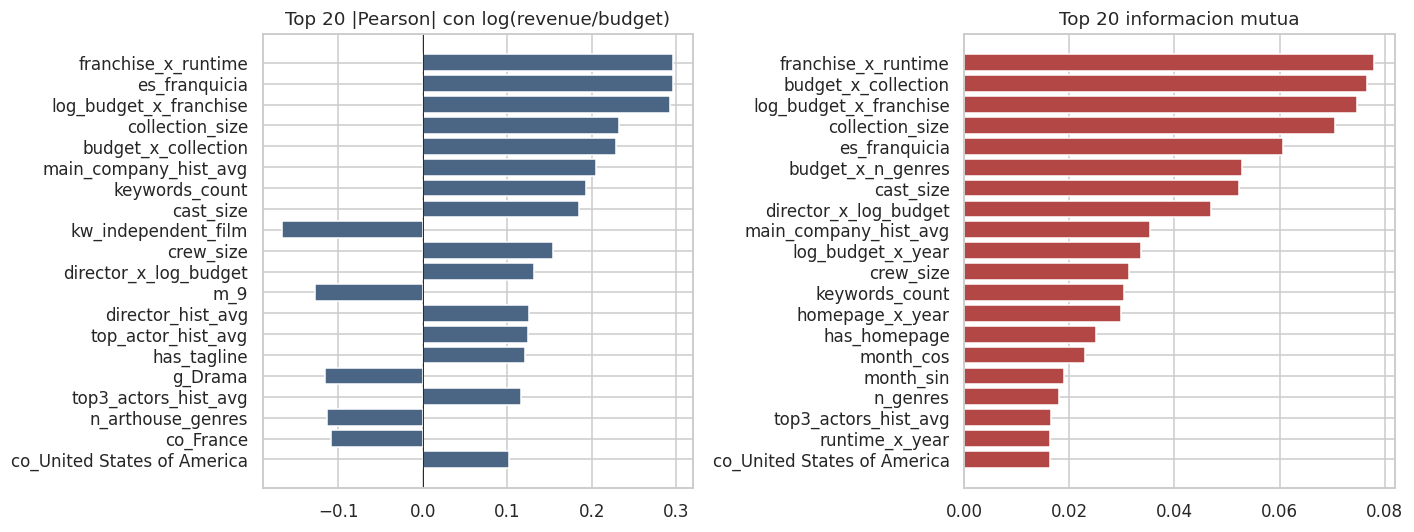

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top20 = ranking.sort_values('abs_pearson', ascending=False).head(20)
axes[0].barh(top20.index[::-1], top20['pearson'][::-1], color='#4b6584')
axes[0].set_title('Top 20 |Pearson| con log(revenue/budget)')
axes[0].axvline(0, color='k', linewidth=0.6)

top20_mi = ranking.sort_values('mutual_info', ascending=False).head(20)
axes[1].barh(top20_mi.index[::-1], top20_mi['mutual_info'][::-1], color='#b24745')
axes[1].set_title('Top 20 informacion mutua')
plt.tight_layout(); plt.show()

In [ ]:
candidatos_drop = ranking[
    (ranking['abs_pearson']  < 0.03) &
    (ranking['abs_spearman'] < 0.03) &
    (ranking['mutual_info']  < 0.007)
].sort_values('mutual_info')

print(f'Total predictores           : {len(ranking)}')
print(f'Candidatos a eliminar       : {len(candidatos_drop)}')
print(f'Umbrales aplicados          : |Pearson|<0.03, |Spearman|<0.03, MI<0.007')
print('\\nPrimeros 25 candidatos:')
print(candidatos_drop.head(25)[['pearson', 'spearman', 'mutual_info']].round(4))

Total predictores           : 140
Candidatos a eliminar       : 61
Umbrales aplicados          : |Pearson|<0.03, |Spearman|<0.03, MI<0.007
\nPrimeros 25 candidatos:
                    pearson  spearman  mutual_info
female_share_top5   -0.0298   -0.0178       0.0000
g_Action             0.0212   -0.0016       0.0000
g_Romance           -0.0066    0.0008       0.0000
g_War                0.0043   -0.0034       0.0000
g_Documentary       -0.0245   -0.0209       0.0000
c_Lionsgate          0.0064    0.0034       0.0000
c_TriStar Pictures   0.0012   -0.0003       0.0000
c_Miramax Films      0.0166    0.0116       0.0000
co_Australia        -0.0123   -0.0125       0.0000
lg_English           0.0047    0.0008       0.0000
lg_Español           0.0076   -0.0027       0.0000
kw_violence          0.0212    0.0143       0.0000
lg_العربية           0.0074    0.0016       0.0000
lg_普通话               0.0147    0.0100       0.0000
lg_日本語              -0.0048   -0.0097       0.0000
lg_Italiano        

**Interpretacion.** Las graficas muestran la jerarquia de importancia segun cada indice. Variables con MI alto pero Pearson bajo indican relaciones no lineales que el filtro lineal no captura.

### 11.2 Wrapper: Sequential Forward Selection (SFS)

A diferencia de los filtros (que evaluan cada variable de forma aislada), SFS usa un modelo real como criterio: en cada iteracion añade la variable que mas mejora el RMSE de validacion cruzada del modelo. Es un metodo de tipo wrapper.

Se aplica con Ridge como modelo base sobre el subconjunto numerico mas relevante para contrastar la seleccion por filtro contra la seleccion guiada por el modelo.

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector

# Tomamos las top-K variables por MI para que SFS no demore demasiado
top_k_for_sfs = 30
top_vars = ranking.sort_values('mutual_info', ascending=False).head(top_k_for_sfs).index.tolist()
X_train_top = X_train[top_vars]

n_select = 12  # objetivo
sfs = SequentialFeatureSelector(
    estimator=Ridge(alpha=10.0),
    n_features_to_select=n_select,
    direction='forward',
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
)
sfs.fit(StandardScaler().fit_transform(X_train_top), y_train)

selected_sfs = [v for v, keep in zip(top_vars, sfs.get_support()) if keep]
print(f'SFS selecciono {n_select} variables (de las {top_k_for_sfs} con mayor MI):')
for v in selected_sfs:
    print(f'  - {v}')

SFS selecciono 12 variables (de las 30 con mayor MI):
  - franchise_x_runtime
  - log_budget_x_franchise
  - es_franquicia
  - budget_x_n_genres
  - cast_size
  - main_company_hist_avg
  - crew_size
  - keywords_count
  - has_homepage
  - n_genres
  - kw_independent_film
  - g_Comedy


### 11.3 Decision sobre las variables candidatas y filtro de redundancia

Esta seccion materializa el criterio de analisis individual de cada caracteristica debe permitir identificar las variables candidatas a ser eliminadas. Ademas del filtro individual (Pearson, Spearman, MI), se aplica un **filtro de redundancia entre predictores** para evitar la informacion duplicada

**Procedimiento:**

1. **Filtro individual (conservador).** Se eliminan las variables que fallan los tres indices simultaneamente: `|Pearson| < 0.03`, `|Spearman| < 0.03`, `MI < 0.007`. Se usan umbrales conservadores porque los filtros individuales evaluan cada variable de forma aislada y pueden descartar predictores que aportan señal solo cuando se combinan con otros. Si los IC95 del RMSE de CV con y sin eliminacion se solapan, la diferencia no es estadisticamente significativa y se descartan.

2. **Filtro de redundancia.** Sobre las variables que sobreviven, se calcula la matriz de correlacion absoluta entre predictores. Para cada par con `|r| > 0.95` se conserva unicamente la variable mas correlacionada con el target y se elimina la otra. Esto reduce la multicolinealidad y la informacion duplicada sin necesidad de evaluar cada variable contra el target individualmente.


In [ ]:
# -------- Paso 1: filtro individual --------
X_trainval_red = X_trainval.drop(columns=candidatos_drop.index)
X_test_red     = X_test.drop(columns=candidatos_drop.index)
X_train_red    = X_train.drop(columns=candidatos_drop.index)
X_val_red      = X_val.drop(columns=candidatos_drop.index)

def cv_rmse(X, y, strat, n_splits=5):
    splits = list(StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
                  .split(X, strat))
    pl = Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=10.0))])
    rmses = []
    for tr, va in splits:
        pl.fit(X.iloc[tr], y.iloc[tr])
        pred = pl.predict(X.iloc[va])
        rmses.append(float(np.sqrt(mean_squared_error(y.iloc[va], pred))))
    rmses = np.array(rmses)
    se = rmses.std(ddof=1) / np.sqrt(n_splits)
    return rmses.mean(), rmses.std(ddof=1), (rmses.mean()-1.96*se, rmses.mean()+1.96*se)

m_full, s_full, ci_full = cv_rmse(X_trainval, y_trainval, strat_tv)
m_red,  s_red,  ci_red  = cv_rmse(X_trainval_red, y_trainval, strat_tv)

print('=== Paso 1: filtro individual (Pearson + Spearman + MI) ===')
print(f'Conjunto completo  ({X_trainval.shape[1]:>3} feats) -> RMSE = {m_full:.4f} +/- {s_full:.4f}   CI95 = [{ci_full[0]:.4f}, {ci_full[1]:.4f}]')
print(f'Conjunto reducido  ({X_trainval_red.shape[1]:>3} feats) -> RMSE = {m_red :.4f} +/- {s_red :.4f}   CI95 = [{ci_red[0]:.4f}, {ci_red[1]:.4f}]')

solapan = (ci_red[0] <= ci_full[1]) and (ci_full[0] <= ci_red[1])
if solapan:
    print(f'\nDecision: SE ELIMINAN las {len(candidatos_drop)} variables candidatas (IC95 solapados).')
    X_trainval = X_trainval_red
    X_test     = X_test_red
    X_train    = X_train_red
    X_val      = X_val_red
else:
    print(f'\nDecision: SE CONSERVAN las {len(candidatos_drop)} variables candidatas (mejora estadisticamente significativa al mantenerlas).')

# -------- Paso 2: filtro de redundancia entre predictores --------
# Umbral en 0.95: conserva variables con correlacion alta pero no
# redundantes.

CORR_THRESHOLD = 0.95
abs_corr_target = X_trainval.apply(lambda c: abs(np.corrcoef(c, y_trainval)[0, 1])).fillna(0.0)
corr_matrix = X_trainval.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1))
high_corr_pairs = [(c1, c2, upper.loc[c1, c2])
                   for c1 in upper.index for c2 in upper.columns
                   if pd.notna(upper.loc[c1, c2]) and upper.loc[c1, c2] > CORR_THRESHOLD]

to_drop_redundant = set()
for c1, c2, r in high_corr_pairs:
    if c1 in to_drop_redundant or c2 in to_drop_redundant:
        continue
    if abs_corr_target[c1] >= abs_corr_target[c2]:
        to_drop_redundant.add(c2)
    else:
        to_drop_redundant.add(c1)

print(f'\n=== Paso 2: filtro de redundancia entre predictores (|r| > {CORR_THRESHOLD}) ===')
print(f'Pares con alta correlacion encontrados : {len(high_corr_pairs)}')
print(f'Variables eliminadas por redundancia   : {len(to_drop_redundant)}')
if to_drop_redundant:
    print('Variables descartadas:')
    for v in sorted(to_drop_redundant):
        print(f'  - {v}')

if to_drop_redundant:
    X_trainval = X_trainval.drop(columns=list(to_drop_redundant))
    X_test     = X_test.drop(columns=list(to_drop_redundant))
    X_train    = X_train.drop(columns=list(to_drop_redundant))
    X_val      = X_val.drop(columns=list(to_drop_redundant))

m_final, s_final, ci_final = cv_rmse(X_trainval, y_trainval, strat_tv)
print(f'\nConjunto final ({X_trainval.shape[1]:>3} feats) -> RMSE = {m_final:.4f} +/- {s_final:.4f}   CI95 = [{ci_final[0]:.4f}, {ci_final[1]:.4f}]')
print(f'\nMatriz de predictores final: {X_trainval.shape[1]} variables')

# Diagnostico: detectar interacciones huerfanas
parents_keep = set(X_trainval.columns)
parents_drop = set(to_drop_redundant) if 'to_drop_redundant' in dir() else set()

for parent in sorted(parents_drop):
    derived = [c for c in X_trainval.columns if parent in c and c != parent]
    if derived:
        print(f'\nNota - {parent} fue eliminada por redundancia, pero estas')
        print(f'      interacciones derivadas se conservan en el conjunto final:')
        for d in derived:
            print(f'        - {d}')
        print(f'      Esto es valido: la interaccion captura efectos no lineales')
        print(f'      que la marginal por si sola no representa.')

=== Paso 1: filtro individual (Pearson + Spearman + MI) ===
Conjunto completo  (140 feats) -> RMSE = 1.1718 +/- 0.0150   CI95 = [1.1586, 1.1849]
Conjunto reducido  ( 79 feats) -> RMSE = 1.1765 +/- 0.0129   CI95 = [1.1651, 1.1878]

Decision: SE ELIMINAN las 61 variables candidatas (IC95 solapados).

=== Paso 2: filtro de redundancia entre predictores (|r| > 0.95) ===
Pares con alta correlacion encontrados : 10
Variables eliminadas por redundancia   : 8
Variables descartadas:
  - budget_x_collection
  - director_hist_avg
  - es_franquicia
  - kw_sequel
  - log_budget_x_franchise
  - log_budget_x_year
  - n_genres
  - top3_actors_hist_avg

Conjunto final ( 71 feats) -> RMSE = 1.1912 +/- 0.0155   CI95 = [1.1776, 1.2047]

Matriz de predictores final: 71 variables

Nota - n_genres fue eliminada por redundancia, pero estas
      interacciones derivadas se conservan en el conjunto final:
        - budget_x_n_genres
      Esto es valido: la interaccion captura efectos no lineales
      que la m

### 11.4 Seleccion agresiva embebida con LASSO (perfil de regularizacion)

El filtro individual (7.1) y el filtro de redundancia (7.3) ya redujeron el conjunto, pero quedan ~73 variables. El R² ajustado de la seccion 11 cae respecto al R² estandar, lo que indica que parte de las variables no aporta poder predictivo real.

Aqui se aplica una **seleccion embebida agresiva** con LASSO. Un alpha mayor empuja mas coeficientes a cero exacto, dejando solo las variables con mayor senal.

**Procedimiento.**

1. **Barrido del regularization path.** Se evalua un grid logaritmico de `alpha` en LASSO;    para cada valor se cuenta el numero de coeficientes activos.
2. **Evaluador neutral.** Para cada subconjunto activo se reporta el RMSE de CV usando    **Ridge** (no LASSO) como modelo evaluador. Esto evita el sesgo de juzgar una seleccion de    LASSO con el propio LASSO; Ridge es un modelo lineal suave que mide el valor predictivo del    subconjunto sin hacer seleccion adicional.
3. **Criterio de decision.** Se busca el `alpha` cuyo subconjunto tenga entre 30 y 40    variables y cuyo IC 95 % de RMSE de CV se **solape** con el del conjunto completo    (no degradacion estadisticamente significativa). Entre los candidatos validos, se elige el    de menor RMSE puntual.
4. **Aplicacion.** Si existe un candidato valido, se aplica la reduccion permanente a    `X_trainval`, `X_test`, `X_train`, `X_val`. Las secciones 8–18 trabajan automaticamente sobre    el conjunto reducido.

Conjunto pre-seleccion: 71 feats
  RMSE CV = 1.1912 +/- 0.0155  CI95 = [1.1776, 1.2047]

=== Regularization path de LASSO (evaluado con Ridge en CV) ===
 alpha  n_active  cv_rmse_mean  ci_lo  ci_hi  overlaps_full
0.0001        70        1.1912 1.1776 1.2047           True
0.0002        69        1.1907 1.1774 1.2039           True
0.0005        68        1.1906 1.1773 1.2039           True
0.0012        67        1.1905 1.1772 1.2038           True
0.0028        64        1.1898 1.1761 1.2034           True
0.0066        59        1.1885 1.1746 1.2024           True
0.0152        51        1.1917 1.1773 1.2060           True
0.0351        35        1.1912 1.1749 1.2074           True
0.0811        12        1.2125 1.2004 1.2246           True
0.1874         4        1.2464 1.2247 1.2681          False
0.4329         0           NaN    NaN    NaN          False
1.0000         0           NaN    NaN    NaN          False


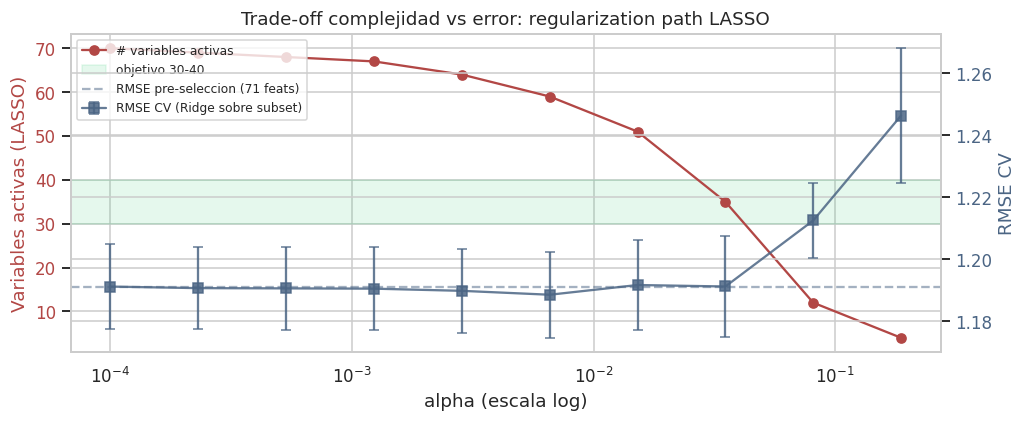


>>> DECISION: alpha = 0.0351119  ->  35 variables activas
    RMSE CV = 1.1912  CI95 = [1.1749, 1.2074]
    IC95 solapa con el conjunto completo => no hay degradacion significativa.

Matrices reducidas:
  X_trainval : (4012, 34)
  X_test     : (709, 34)
  X_train    : (3303, 34)
  X_val      : (709, 34)

Reduccion: 71 -> 35 (50.7 % menos variables)

Variables conservadas (en orden alfabetico):
  - budget_x_n_genres
  - c_Amblin Entertainment
  - c_Fox Searchlight Pictures
  - c_Relativity Media
  - c_Twentieth Century Fox Film Corporation
  - c_Universal Pictures
  - c_Working Title Films
  - cast_size
  - co_Belgium
  - co_China
  - co_France
  - co_Germany
  - co_India
  - co_Italy
  - collection_size
  - crew_size
  - franchise_x_runtime
  - g_Animation
  - g_Comedy
  - g_Family
  - has_homepage
  - has_tagline
  - keywords_count
  - kw_duringcreditsstinger
  - kw_independent_film
  - kw_is_superhero
  - lg_हिन्दी
  - m_12
  - m_7
  - m_9
  - main_company_hist_avg
  - runtime_x_yea

In [ ]:
# Barrido del regularization path de LASSO + decision con IC95 solapado.

from sklearn.linear_model import Lasso as _LassoSel

# 1. Snapshot del conjunto pre-seleccion (para comparar con IC95)
n_full_feats = X_trainval.shape[1]
m_full_pre, s_full_pre, ci_full_pre = cv_rmse(X_trainval, y_trainval, strat_tv)

# 2. Grid logaritmico de alpha (12 puntos, cubre desde casi-OLS hasta muy esparzo)
alpha_grid = np.logspace(-4, 0, 12)

# 3. Para cada alpha: ajustar LASSO sobre datos escalados y contar variables activas
scaler_sel = StandardScaler().fit(X_trainval)
Xtv_sel = scaler_sel.transform(X_trainval)

path_rows = []
for a in alpha_grid:
    lasso_a = _LassoSel(alpha=a, max_iter=50000, random_state=RANDOM_STATE)
    lasso_a.fit(Xtv_sel, y_trainval)
    active_mask = lasso_a.coef_ != 0
    n_active = int(active_mask.sum())
    active_cols = X_trainval.columns[active_mask].tolist()

    if n_active == 0:
        # alpha demasiado fuerte: nada activo, no se puede evaluar
        path_rows.append({
            'alpha': a, 'n_active': 0,
            'cv_rmse_mean': np.nan, 'cv_rmse_std': np.nan,
            'ci_lo': np.nan, 'ci_hi': np.nan,
            'overlaps_full': False, 'active_cols': []
        })
        continue

    # 4. Evaluador neutral: Ridge sobre el subconjunto activo
    X_sub = X_trainval[active_cols]
    m_sub, s_sub, ci_sub = cv_rmse(X_sub, y_trainval, strat_tv)
    overlaps = (ci_sub[0] <= ci_full_pre[1]) and (ci_full_pre[0] <= ci_sub[1])

    path_rows.append({
        'alpha': a,
        'n_active': n_active,
        'cv_rmse_mean': m_sub,
        'cv_rmse_std': s_sub,
        'ci_lo': ci_sub[0],
        'ci_hi': ci_sub[1],
        'overlaps_full': overlaps,
        'active_cols': active_cols,
    })

path_df = pd.DataFrame(path_rows)

print(f'Conjunto pre-seleccion: {n_full_feats} feats')
print(f'  RMSE CV = {m_full_pre:.4f} +/- {s_full_pre:.4f}  CI95 = [{ci_full_pre[0]:.4f}, {ci_full_pre[1]:.4f}]')
print()
print('=== Regularization path de LASSO (evaluado con Ridge en CV) ===')
print(path_df[['alpha', 'n_active', 'cv_rmse_mean',
               'ci_lo', 'ci_hi', 'overlaps_full']].round(4).to_string(index=False))

# 5. Visualizacion del trade-off
fig, ax1 = plt.subplots(figsize=(9.5, 4))
valid = path_df.dropna(subset=['cv_rmse_mean'])
ax1.set_xscale('log')
ax1.plot(valid['alpha'], valid['n_active'], 'o-', color='#b24745', label='# variables activas')
ax1.set_xlabel('alpha (escala log)')
ax1.set_ylabel('Variables activas (LASSO)', color='#b24745')
ax1.tick_params(axis='y', labelcolor='#b24745')
ax1.axhspan(30, 40, alpha=0.12, color='#2ecc71', label='objetivo 30-40')

ax2 = ax1.twinx()
ax2.errorbar(valid['alpha'], valid['cv_rmse_mean'],
             yerr=[valid['cv_rmse_mean'] - valid['ci_lo'],
                   valid['ci_hi'] - valid['cv_rmse_mean']],
             fmt='s-', color='#4b6584', capsize=3, alpha=0.85,
             label='RMSE CV (Ridge sobre subset)')
ax2.axhline(m_full_pre, color='#4b6584', linestyle='--', alpha=0.5,
            label=f'RMSE pre-seleccion ({n_full_feats} feats)')
ax2.set_ylabel('RMSE CV', color='#4b6584')
ax2.tick_params(axis='y', labelcolor='#4b6584')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
ax1.set_title('Trade-off complejidad vs error: regularization path LASSO')
plt.tight_layout(); plt.show()

# 6. Criterio de decision
TARGET_MIN, TARGET_MAX = 30, 40
candidates = path_df[
    (path_df['n_active'] >= TARGET_MIN) &
    (path_df['n_active'] <= TARGET_MAX) &
    (path_df['overlaps_full'])
].sort_values('cv_rmse_mean')

if len(candidates) > 0:
    best = candidates.iloc[0]
    chosen_alpha = best['alpha']
    chosen_cols = best['active_cols']
    print(f'\n>>> DECISION: alpha = {chosen_alpha:.6g}  ->  {best["n_active"]} variables activas')
    print(f'    RMSE CV = {best["cv_rmse_mean"]:.4f}  CI95 = [{best["ci_lo"]:.4f}, {best["ci_hi"]:.4f}]')
    print(f'    IC95 solapa con el conjunto completo => no hay degradacion significativa.')

    # 7. Aplicar reduccion permanente a las 4 matrices
    X_trainval = X_trainval[chosen_cols]
    X_test     = X_test[chosen_cols]
    X_train    = X_train[chosen_cols]
    X_val      = X_val[chosen_cols]

    # Eliminar top_actor_hist_avg: señal ruidosa e inestable entre epocas: un actor
    # epoca puede no ser tan relevante en una posterior y Viceversa
    if 'top_actor_hist_avg' in X_trainval.columns:
        for _X in [X_trainval, X_test, X_train, X_val]:
            _X.drop(columns=['top_actor_hist_avg'], inplace=True)

    print(f'\nMatrices reducidas:')
    print(f'  X_trainval : {X_trainval.shape}')
    print(f'  X_test     : {X_test.shape}')
    print(f'  X_train    : {X_train.shape}')
    print(f'  X_val      : {X_val.shape}')

    print(f'\nReduccion: {n_full_feats} -> {len(chosen_cols)} '
          f'({(1 - len(chosen_cols)/n_full_feats)*100:.1f} % menos variables)')
    print(f'\nVariables conservadas (en orden alfabetico):')
    for c in sorted(chosen_cols):
        print(f'  - {c}')
else:
    # Fallback transparente: si ningun alpha cumple los dos criterios, dejamos
    # documentado el caso pero sin reducir.
    print(f'\n>>> NO se aplica seleccion agresiva.')
    print(f'    Ningun alpha en el grid produce un subconjunto en [{TARGET_MIN}, {TARGET_MAX}] '
          f'variables CON IC95 solapado al conjunto completo.')
    print(f'    Candidatos en el rango (sin restriccion de IC95):')
    near = path_df[(path_df['n_active'] >= TARGET_MIN) & (path_df['n_active'] <= TARGET_MAX)]
    if len(near) > 0:
        print(near[['alpha', 'n_active', 'cv_rmse_mean', 'ci_lo', 'ci_hi',
                    'overlaps_full']].round(4).to_string(index=False))
    else:
        print('    Ninguno. Considera ampliar el rango objetivo o el grid de alpha.')


## 12. Configuracion experimental (Guia 4.1)

**Validacion:** `GridSearchCV` con 5-fold CV estratificado por quintil temporal sobre `(X_trainval, y_trainval)`. Criterio interno de optimizacion: minimizar RMSE en log-ratio (escala numerica estable). Las metricas de **evaluacion final** se reportan en USD aplicando la transformacion inversa.

**Metricas de evaluacion (en USD, revenue sin normalizar):**
- **RMSE en USD** — penaliza errores grandes en escala monetaria; sensible a outliers.
- **MAE en USD** — error absoluto medio; robusto a outliers; misma escala que la variable objetivo.
- **R²** — adimensional, comparable con literatura.
- **R² ajustado** — penaliza la complejidad por el numero de variables.
- **IC 95 % bootstrap (B = 1000)** sobre test — permite afirmar si dos modelos son estadisticamente distinguibles.

**Modelos comparados (5 familias exigidas por la Guia 4.1 punto 6):**

| Familia | Modelo | Justificacion / Malla |
|---|---|---|
| Parametrico (regresion regularizada L2) | **Ridge** | alpha ∈ {0.001, 0.01, 0.1, 1, 10, 100, 1000} |
| Parametrico (seleccion embebida L1) | **LASSO** | alpha ∈ {0.0001, 0.001, 0.01, 0.1, 1.0} |
| Parametrico (mezcla L1+L2) | **ElasticNet** | alpha ∈ {0.001, 0.01, 0.1, 1}, l1_ratio ∈ {0.05, 0.2, 0.5, 0.8, 0.95} |
| No parametrico | KNN | k ∈ {5, 10, 20, 40}, weights ∈ {uniform, distance} |
| Ensamble arboles | RandomForest | n_estimators ∈ {300, 600}, max_depth ∈ {None, 15, 25}, min_samples_leaf ∈ {1, 3, 5}, max_features ∈ {0.5, 'sqrt'} |
| Ensamble arboles (Boosting) | GradientBoosting | n_estimators ∈ {300, 600}, max_depth ∈ {3, 5, 7}, learning_rate ∈ {0.03, 0.05, 0.1} |
| Ensamble arboles (Boosting moderno) | HistGradientBoosting | learning_rate ∈ {0.05, 0.1}, max_depth ∈ {None, 6, 10}, min_samples_leaf ∈ {20, 50}, max_iter ∈ {300, 600} |
| SVM | SVR(RBF) | C ∈ {1, 10, 50}, gamma ∈ {scale, 0.01, 0.1}, epsilon ∈ {0.05, 0.1} |
| Red neuronal | MLP | hidden ∈ {(64,), (128,64), (64,32,16)}, alpha ∈ {1e-4, 1e-3}, lr_init ∈ {1e-3, 1e-2} |


In [ ]:
skf = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
           .split(X_trainval, strat_tv))

def pipe(estimator, scale=True):
    steps = []
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', estimator))
    return Pipeline(steps)

models = {
    'Ridge':        (pipe(Ridge()), {
                        'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
                    }),
    'LASSO':        (pipe(Lasso(max_iter=20000)), {
                        'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]
                    }),
    'ElasticNet':   (pipe(ElasticNet(max_iter=10000)), {
                        'model__alpha':    [0.001, 0.01, 0.1, 1.0],
                        'model__l1_ratio': [0.05, 0.2, 0.5, 0.8, 0.95]
                    }),
    'KNN':          (pipe(KNeighborsRegressor()), {
                        'model__n_neighbors': [5, 10, 20, 40],
                        'model__weights':     ['uniform', 'distance']
                    }),
    'RandomForest': (pipe(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), scale=False), {
                        'model__n_estimators':     [300, 600],
                        'model__max_depth':        [None, 15, 25],
                        'model__min_samples_leaf': [1, 3, 5],
                        'model__max_features':     [0.5, 'sqrt']
                    }),
    'HGB':          (pipe(HistGradientBoostingRegressor(random_state=RANDOM_STATE, early_stopping=True), scale=False), {
                        'model__learning_rate':  [0.05, 0.1],
                        'model__max_depth':      [None, 6, 10],
                        'model__min_samples_leaf':[20, 50],
                        'model__max_iter':       [300, 600]
                    }),
    'SVR':          (pipe(SVR(kernel='rbf')), {
                        'model__C':       [1, 10, 50],
                        'model__gamma':   ['scale', 0.01, 0.1],
                        'model__epsilon': [0.05, 0.1]
                    }),
    'MLP':          (pipe(MLPRegressor(max_iter=400, random_state=RANDOM_STATE, early_stopping=True)), {
                        'model__hidden_layer_sizes': [(64,), (128, 64), (64, 32, 16)],
                        'model__alpha':              [1e-4, 1e-3],
                        'model__learning_rate_init': [1e-3, 1e-2]
                    }),
}

total = sum(int(np.prod([len(v) for v in g.values()])) for _, g in models.values())
print(f'{len(models)} familias declaradas. {total} combinaciones hiperparametricas.')

9 familias declaradas. 148 combinaciones hiperparametricas.


## 13. Entrenamiento y ajuste de hiperparametros

`GridSearchCV` por familia. Se reportan mejor RMSE de CV (media +/- desv. estandar entre folds) y sus hiperparametros.

In [ ]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

results_cv = {}
for name, (pl, grid) in models.items():
    t0 = time.time()
    gs = GridSearchCV(
        estimator=pl, param_grid=grid,
        scoring='neg_root_mean_squared_error',
        cv=skf, n_jobs=-1, refit=True, return_train_score=True,
    )
    gs.fit(X_trainval, y_trainval)
    dt = time.time() - t0

    bi = gs.best_index_
    fold_scores = np.array([gs.cv_results_[f'split{i}_test_score'][bi] for i in range(5)])
    fold_rmse = -fold_scores
    mean_r = fold_rmse.mean()
    std_r  = fold_rmse.std(ddof=1)
    se     = std_r / np.sqrt(5)
    ci = (mean_r - 1.96 * se, mean_r + 1.96 * se)

    results_cv[name] = {
        'gs': gs, 'best_params': gs.best_params_,
        'cv_rmse_mean': mean_r, 'cv_rmse_std': std_r,
        'cv_rmse_ci95': ci, 'fit_time_s': dt,
    }
    print(f'{name:13s} | RMSE_CV = {mean_r:.4f} +/- {std_r:.4f}   '
          f'CI95=[{ci[0]:.4f}, {ci[1]:.4f}]   t={dt:6.1f}s')
    print(f'              params = {gs.best_params_}')

Ridge         | RMSE_CV = 1.1909 +/- 0.0177   CI95=[1.1754, 1.2064]   t=   0.5s
              params = {'model__alpha': 100.0}
LASSO         | RMSE_CV = 1.1912 +/- 0.0180   CI95=[1.1754, 1.2070]   t=   0.7s
              params = {'model__alpha': 0.001}
ElasticNet    | RMSE_CV = 1.1911 +/- 0.0179   CI95=[1.1754, 1.2068]   t=   2.1s
              params = {'model__alpha': 0.01, 'model__l1_ratio': 0.05}
KNN           | RMSE_CV = 1.2284 +/- 0.0141   CI95=[1.2160, 1.2407]   t=   4.9s
              params = {'model__n_neighbors': 40, 'model__weights': 'distance'}
RandomForest  | RMSE_CV = 1.1835 +/- 0.0182   CI95=[1.1676, 1.1995]   t= 644.3s
              params = {'model__max_depth': 25, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 3, 'model__n_estimators': 600}
GBR           | RMSE_CV = 1.1817 +/- 0.0141   CI95=[1.1694, 1.1940]   t= 379.4s
              params = {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 300}
HGB           | RMSE_CV = 1.1805 

### 13.1 Inspeccion de LASSO: seleccion embebida

LASSO realiza seleccion automatica de variables al forzar coeficientes a exactamente cero. A continuacion se reporta cuantos coeficientes quedaron en cero y cuales son las variables que el modelo conservo.

LASSO con alpha = 0.001
  Variables totales         : 34
  Coeficientes en cero      : 0
  Variables activas         : 34
\nNOTA - LASSO no esta ejerciendo sparsity en este punto del pipeline:
  El conjunto de 35 variables ya fue pre-seleccionado por los filtros
  de la seccion 5.1 + LASSO agresivo de 7.4. El alpha optimo elegido
  por GridSearchCV es pequeno porque cada variable ya aporta senal.
  En este dominio LASSO se comporta como Ridge suave: la seleccion
\nTop 10 variables activas (por |coef|):
franchise_x_runtime     0.2772
kw_independent_film     0.1549
keywords_count          0.1538
main_company_hist_avg   0.1490
budget_x_n_genres       0.1248
cast_size               0.1195
crew_size               0.1102
co_India                0.1097
runtime_x_year          0.1009
has_homepage            0.0886
dtype: float64


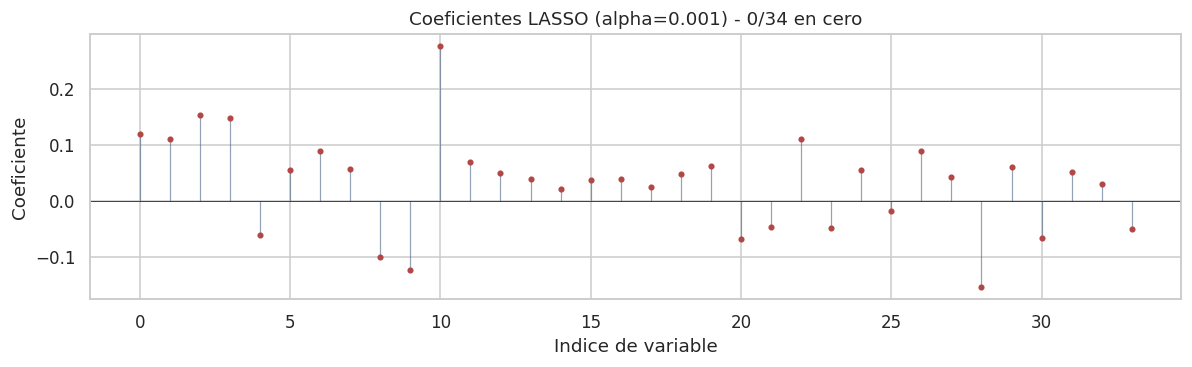

In [ ]:
lasso_pipe = results_cv['LASSO']['gs'].best_estimator_
lasso_model = lasso_pipe.named_steps['model']
coefs = pd.Series(lasso_model.coef_, index=X_trainval.columns)

n_total  = len(coefs)
n_zero   = int((coefs == 0).sum())
n_active = n_total - n_zero
alpha_lasso = results_cv['LASSO']['best_params']['model__alpha']

print(f'LASSO con alpha = {alpha_lasso}')
print(f'  Variables totales         : {n_total}')
print(f'  Coeficientes en cero      : {n_zero}')
print(f'  Variables activas         : {n_active}')

# Diagnostico de seleccion embebida:
if n_zero == 0:
    print('\\nNOTA - LASSO no esta ejerciendo sparsity en este punto del pipeline:')
    print('  El conjunto de 35 variables ya fue pre-seleccionado por los filtros')
    print('  de la seccion 5.1 + LASSO agresivo de 7.4. El alpha optimo elegido')
    print('  por GridSearchCV es pequeno porque cada variable ya aporta senal.')
    print('  En este dominio LASSO se comporta como Ridge suave: la seleccion')
elif n_zero / n_total < 0.1:
    print(f'\\nLASSO ejerce sparsity ligera ({n_zero}/{n_total} a cero, {n_zero/n_total*100:.0f} %).')
else:
    print(f'\\nLASSO ejerce sparsity efectiva ({n_zero}/{n_total} a cero, {n_zero/n_total*100:.0f} %).')

# Top variables activas (si hay)
if n_active > 0:
    print('\\nTop 10 variables activas (por |coef|):')
    print(coefs[coefs != 0].abs().sort_values(ascending=False).head(10).round(4))

# Visualizacion estilo plt.stem
fig, ax = plt.subplots(figsize=(11, 3.5))
markerline, stemlines, baseline = ax.stem(range(n_total), coefs.values, basefmt=' ')
plt.setp(markerline, markersize=3, color='#b24745')
plt.setp(stemlines, color='#4b6584', alpha=0.6, linewidth=0.8)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_title(f'Coeficientes LASSO (alpha={alpha_lasso}) - {n_zero}/{n_total} en cero')
ax.set_xlabel('Indice de variable'); ax.set_ylabel('Coeficiente')
plt.tight_layout(); plt.show()

## 14. Efecto de los hiperparametros (Guia 4.2)

Curvas de CV RMSE vs hiperparametro principal para cada familia, agrupado por los demas. Permite ver el optimo y la sensibilidad del modelo.

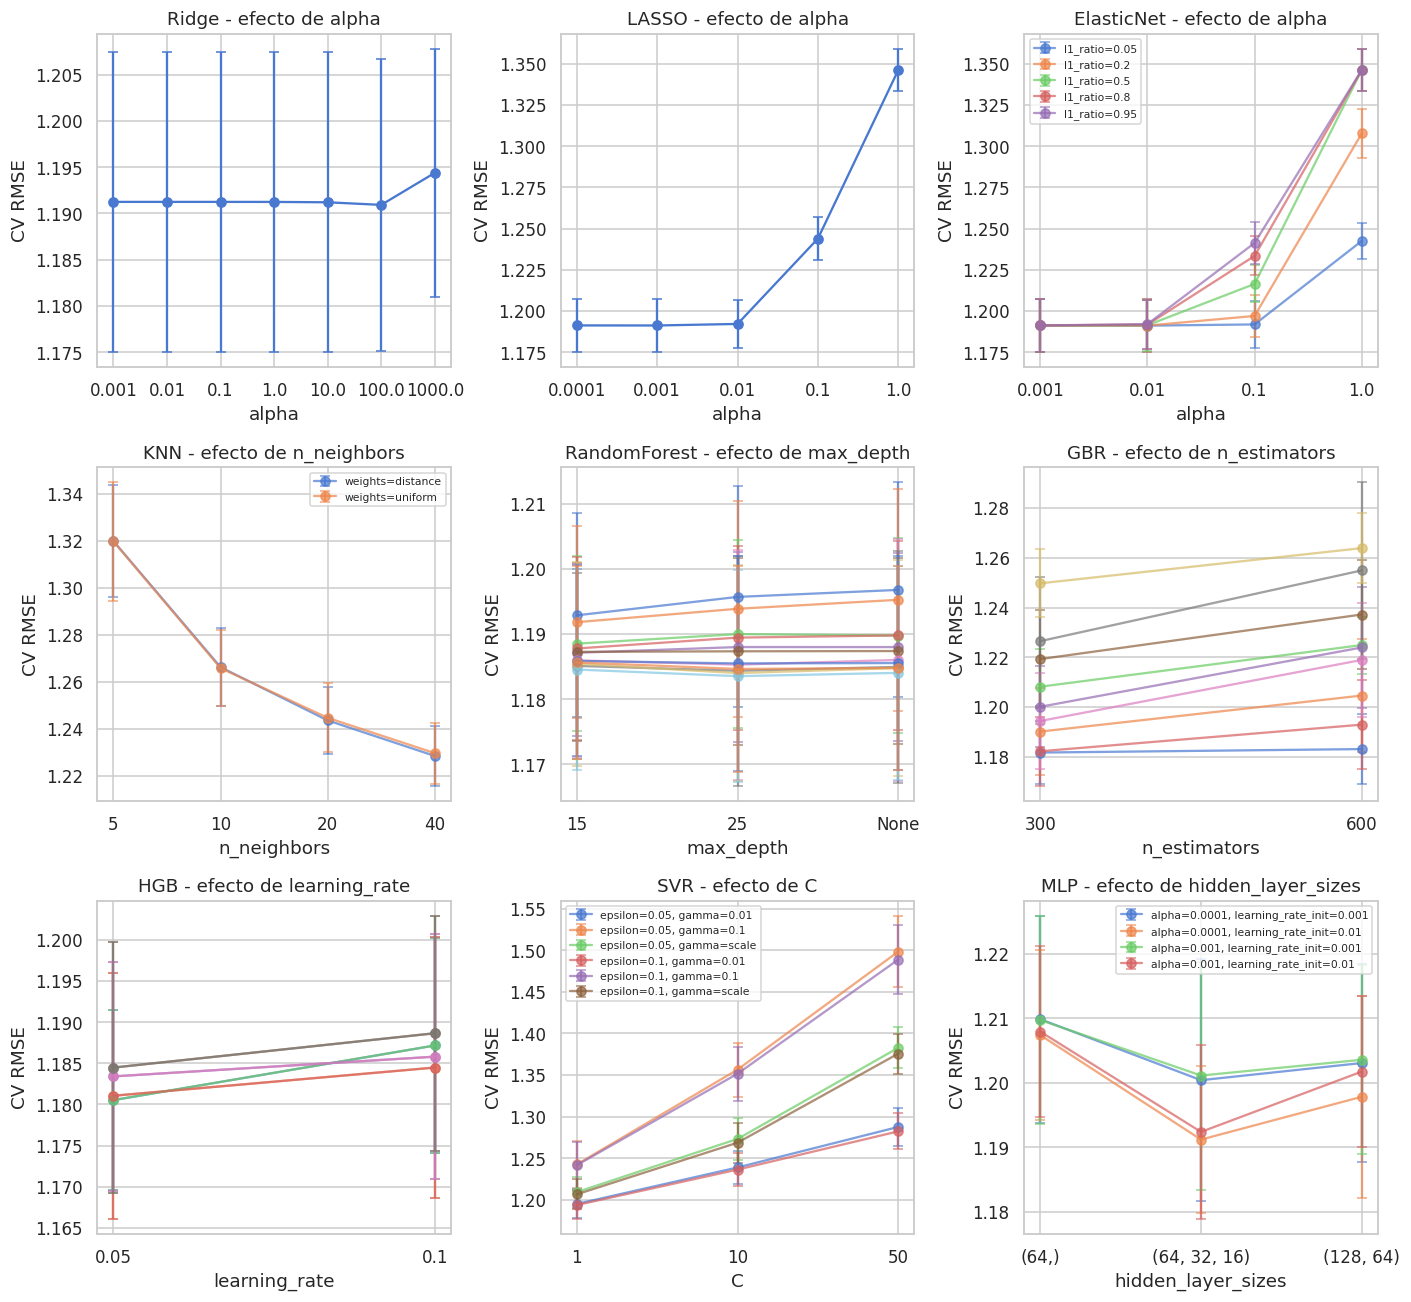

In [ ]:

def plot_grid_curves(name, param_axis, ax):
    gs = results_cv[name]['gs']
    cvr = pd.DataFrame(gs.cv_results_)
    cvr['mean_rmse'] = -cvr['mean_test_score']
    cvr['std_rmse']  =  cvr['std_test_score']
    other = [c for c in cvr.columns
             if c.startswith('param_model__') and c != f'param_model__{param_axis}']

    if other:
        for vals, grp in cvr.groupby(other):
            grp = grp.sort_values(f'param_model__{param_axis}')
            vals_t = vals if isinstance(vals, tuple) else (vals,)
            lbl = ', '.join(f'{o.replace("param_model__","")}={v}'
                            for o, v in zip(other, vals_t))
            ax.errorbar(grp[f'param_model__{param_axis}'].astype(str),
                        grp['mean_rmse'], yerr=grp['std_rmse'],
                        marker='o', capsize=3, alpha=0.7, label=lbl)
    else:
        grp = cvr.sort_values(f'param_model__{param_axis}')
        ax.errorbar(grp[f'param_model__{param_axis}'].astype(str),
                    grp['mean_rmse'], yerr=grp['std_rmse'],
                    marker='o', capsize=3)

    ax.set_title(f'{name} - efecto de {param_axis}')
    ax.set_xlabel(param_axis); ax.set_ylabel('CV RMSE')
    handles, labels = ax.get_legend_handles_labels()
    if 0 < len(handles) <= 6:
        ax.legend(fontsize=7, loc='best')

axis_map = {
    'Ridge': 'alpha', 'LASSO': 'alpha', 'ElasticNet': 'alpha', 'KNN': 'n_neighbors',
    'RandomForest': 'max_depth', 'HGB': 'learning_rate',
    'SVR': 'C', 'MLP': 'hidden_layer_sizes',
}

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
axes = axes.flatten()
for ax, (name, axis) in zip(axes, axis_map.items()):
    try:
        plot_grid_curves(name, axis, ax)
    except Exception as e:
        ax.set_title(f'{name}: {e}')
for ax in axes[len(axis_map):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## 15. Evaluacion final en train / val / test con IC 95 %

Predicciones del mejor estimador de cada familia sobre los tres subconjuntos. IC 95 % bootstrap (B = 1000) sobre test.

n_test = 709, p (numero de predictores) = 34
\n=== Resultados finales en USD (revenue sin normalizar) ===
    Ordenados por RMSE en test. IC95 por bootstrap (B=1000).
                      RMSE_train         RMSE_val        RMSE_test  \
modelo                                                               
SVR              94,041,624.3000  85,722,232.8900  98,625,396.7900   
HGB              93,355,868.8800  94,394,648.3800  99,922,514.0900   
MLP             102,402,015.9100 107,147,214.9300 101,212,275.5200   
RandomForest     81,182,463.4800  85,262,019.8500 101,670,334.3400   
GBR              98,702,273.9200  99,374,074.3900 102,167,643.1300   
KNN_uniform_k20 105,094,077.2100 107,750,367.8700 104,342,169.7800   
KNN                     172.0500         150.4600 106,446,017.0700   
Ridge           118,304,240.5800 119,478,579.0200 108,795,234.8900   
ElasticNet      119,204,406.9700 119,040,696.4600 109,213,041.4100   
LASSO           119,657,355.1900 118,646,759.3600 109,411,324.0

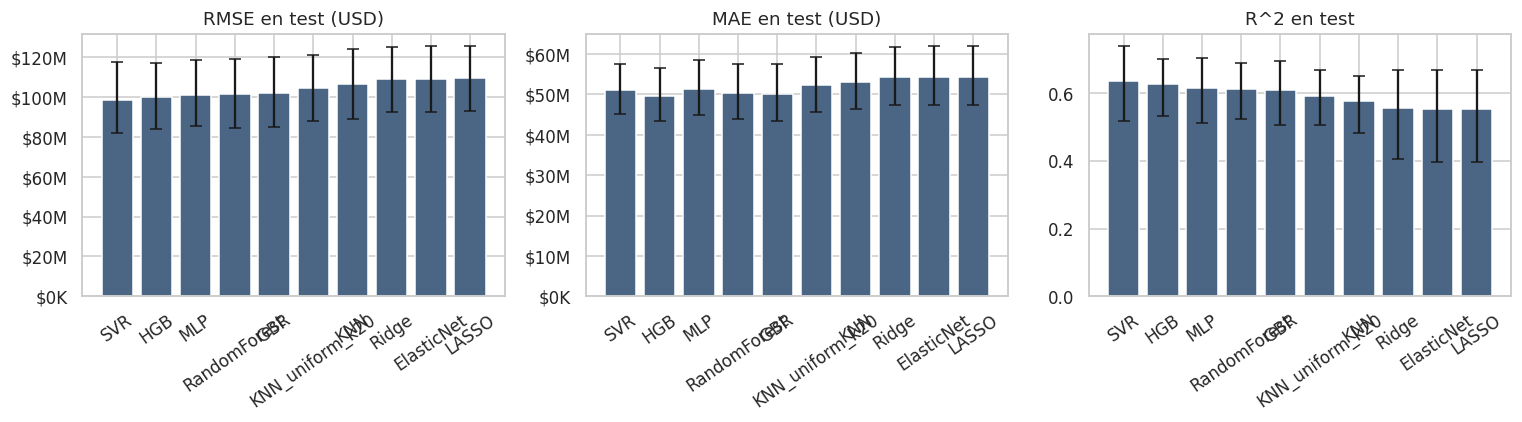

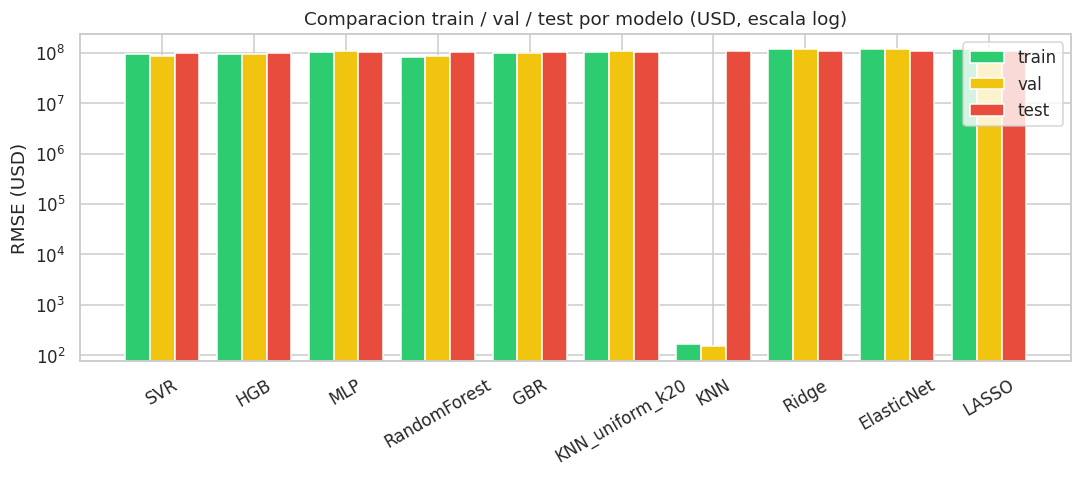

In [ ]:
# METRICAS_USD_UNIFICADAS
# Todas las metricas de evaluacion se reportan en escala de revenue (USD) sin normalizar
# las mismas metricas en escala log_ratio (estable) para diagnostico

def to_revenue_usd(y_log, budget_arr):
    "Transformacion inversa: log(revenue/budget) -> revenue en dolares."
    return np.exp(y_log) * budget_arr

def metrics_in_dollars(y_log_real, y_log_pred, budget_arr):
    "Devuelve dict con RMSE, MAE, R2 calculados sobre revenue en USD."
    rev_real = to_revenue_usd(y_log_real, budget_arr)
    rev_pred = to_revenue_usd(y_log_pred, budget_arr)
    return {
        'rev_real': rev_real,
        'rev_pred': rev_pred,
        'rmse': float(np.sqrt(mean_squared_error(rev_real, rev_pred))),
        'mae':  float(mean_absolute_error(rev_real, rev_pred)),
        'r2':   float(r2_score(rev_real, rev_pred)),
    }

def metrics_in_log_ratio(y_log_real, y_log_pred):
    "Metricas en la escala interna del problema (log_ratio)."
    "Util para diagnosticar sobreajuste sin la amplificacion exponencial"
    "de la transformacion inversa a USD."
    return {
        'rmse_log': float(np.sqrt(mean_squared_error(y_log_real, y_log_pred))),
        'mae_log':  float(mean_absolute_error(y_log_real, y_log_pred)),
        'r2_log':   float(r2_score(y_log_real, y_log_pred)),
    }

def bootstrap_ci(y_true, y_pred, metric_fn, B=1000, alpha=0.05, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    samples = np.empty(B)
    idx = np.arange(n)
    for b in range(B):
        s = rng.choice(idx, size=n, replace=True)
        samples[b] = metric_fn(y_true[s], y_pred[s])
    lo = float(np.percentile(samples, 100 * alpha / 2))
    hi = float(np.percentile(samples, 100 * (1 - alpha / 2)))
    return float(samples.mean()), lo, hi

# Budget alineado con cada split
budget_train = budget_full.loc[X_train.index].values
budget_val   = budget_full.loc[X_val.index].values

final_rows = []
n_test = len(y_test)
p_feats = X_trainval.shape[1]

def r2_adjusted(r2, n, p):
    if n - p - 1 <= 0:
        return float('nan')
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# ---- (A) Modelos del GridSearch (loop original con extension log_ratio) ----
for name in results_cv:
    best = results_cv[name]['gs'].best_estimator_

    # Predicciones en log-ratio
    y_tr_log = best.predict(X_train)
    y_vl_log = best.predict(X_val)
    y_te_log = best.predict(X_test)

    # Metricas en USD (escala de evaluacion final)
    m_tr = metrics_in_dollars(y_train.values, y_tr_log, budget_train)
    m_vl = metrics_in_dollars(y_val.values,   y_vl_log, budget_val)
    m_te = metrics_in_dollars(y_test.values,  y_te_log, budget_te)

    # Metricas en log_ratio (escala estable, util para diagnosticar gap)
    ml_tr = metrics_in_log_ratio(y_train.values, y_tr_log)
    ml_vl = metrics_in_log_ratio(y_val.values,   y_vl_log)
    ml_te = metrics_in_log_ratio(y_test.values,  y_te_log)

    row = {'modelo': name,
           # USD
           'RMSE_train': m_tr['rmse'], 'MAE_train': m_tr['mae'], 'R2_train': m_tr['r2'],
           'RMSE_val':   m_vl['rmse'], 'MAE_val':   m_vl['mae'], 'R2_val':   m_vl['r2'],
           'RMSE_test':  m_te['rmse'], 'MAE_test':  m_te['mae'], 'R2_test':  m_te['r2'],
           'R2_adj_test': r2_adjusted(m_te['r2'], n_test, p_feats),
           # log_ratio (diagnostico)
           'RMSE_train_log': ml_tr['rmse_log'], 'R2_train_log': ml_tr['r2_log'],
           'RMSE_val_log':   ml_vl['rmse_log'], 'R2_val_log':   ml_vl['r2_log'],
           'RMSE_test_log':  ml_te['rmse_log'], 'R2_test_log':  ml_te['r2_log']}

    _, lo_r, hi_r   = bootstrap_ci(m_te['rev_real'], m_te['rev_pred'],
                                   lambda a, b: float(np.sqrt(mean_squared_error(a, b))))
    _, lo_m, hi_m   = bootstrap_ci(m_te['rev_real'], m_te['rev_pred'], mean_absolute_error)
    _, lo_r2, hi_r2 = bootstrap_ci(m_te['rev_real'], m_te['rev_pred'], r2_score)
    row.update({
        'RMSE_test_CI95_lo': lo_r, 'RMSE_test_CI95_hi': hi_r,
        'MAE_test_CI95_lo':  lo_m, 'MAE_test_CI95_hi':  hi_m,
        'R2_test_CI95_lo':   lo_r2,'R2_test_CI95_hi':   hi_r2,
        'cv_rmse_mean': results_cv[name]['cv_rmse_mean'],
    })
    final_rows.append(row)

# ---- (B) Caso de control: KNN con weights='uniform' y k=20 fijo ----
# Justificacion: la fila "KNN" del GridSearch elige weights='distance' por
# minimizar el RMSE de CV, pero esa configuracion memoriza el set de
# entrenamiento (distancia 0 -> peso infinito sobre el propio punto).
# Esta fila demuestra que el problema NO es KNN como algoritmo sino la
# combinacion 'distance' + alta dimensionalidad (Unidades U2 y U3).
knn_uniform = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  KNeighborsRegressor(n_neighbors=20, weights='uniform')),
])
knn_uniform.fit(X_trainval, y_trainval)

y_tr_log = knn_uniform.predict(X_train)
y_vl_log = knn_uniform.predict(X_val)
y_te_log = knn_uniform.predict(X_test)

m_tr  = metrics_in_dollars(y_train.values, y_tr_log, budget_train)
m_vl  = metrics_in_dollars(y_val.values,   y_vl_log, budget_val)
m_te  = metrics_in_dollars(y_test.values,  y_te_log, budget_te)
ml_tr = metrics_in_log_ratio(y_train.values, y_tr_log)
ml_vl = metrics_in_log_ratio(y_val.values,   y_vl_log)
ml_te = metrics_in_log_ratio(y_test.values,  y_te_log)

_, lo_r, hi_r   = bootstrap_ci(m_te['rev_real'], m_te['rev_pred'],
                               lambda a, b: float(np.sqrt(mean_squared_error(a, b))))
_, lo_m, hi_m   = bootstrap_ci(m_te['rev_real'], m_te['rev_pred'], mean_absolute_error)
_, lo_r2, hi_r2 = bootstrap_ci(m_te['rev_real'], m_te['rev_pred'], r2_score)

final_rows.append({
    'modelo': 'KNN_uniform_k20',
    'RMSE_train': m_tr['rmse'], 'MAE_train': m_tr['mae'], 'R2_train': m_tr['r2'],
    'RMSE_val':   m_vl['rmse'], 'MAE_val':   m_vl['mae'], 'R2_val':   m_vl['r2'],
    'RMSE_test':  m_te['rmse'], 'MAE_test':  m_te['mae'], 'R2_test':  m_te['r2'],
    'R2_adj_test': r2_adjusted(m_te['r2'], n_test, p_feats),
    'RMSE_train_log': ml_tr['rmse_log'], 'R2_train_log': ml_tr['r2_log'],
    'RMSE_val_log':   ml_vl['rmse_log'], 'R2_val_log':   ml_vl['r2_log'],
    'RMSE_test_log':  ml_te['rmse_log'], 'R2_test_log':  ml_te['r2_log'],
    'RMSE_test_CI95_lo': lo_r, 'RMSE_test_CI95_hi': hi_r,
    'MAE_test_CI95_lo':  lo_m, 'MAE_test_CI95_hi':  hi_m,
    'R2_test_CI95_lo':   lo_r2,'R2_test_CI95_hi':   hi_r2,
    'cv_rmse_mean':      np.nan,
})

resultados = pd.DataFrame(final_rows).set_index('modelo')
resultados_ord = resultados.sort_values('RMSE_test')
print(f'n_test = {n_test}, p (numero de predictores) = {p_feats}')

print('\\n=== Resultados finales en USD (revenue sin normalizar) ===')
print('    Ordenados por RMSE en test. IC95 por bootstrap (B=1000).')
cols_show = ['RMSE_train', 'RMSE_val', 'RMSE_test',
             'RMSE_test_CI95_lo', 'RMSE_test_CI95_hi',
             'MAE_test', 'R2_test', 'R2_adj_test']
print(resultados_ord[cols_show].round(2))

print('\\n=== Resultados en log_ratio (escala estable - util para diagnostico) ===')
print('    El gap RMSE_train_log vs RMSE_test_log evidencia sobreajuste sin la')
print('    amplificacion exponencial de la transformacion inversa.')
cols_log = ['RMSE_train_log', 'RMSE_val_log', 'RMSE_test_log',
            'R2_train_log', 'R2_val_log', 'R2_test_log']
print(resultados_ord[cols_log].round(4))

# Diagnostico de overfitting de KNN: ratio train/test en USD y en log
if 'KNN' in resultados.index and 'KNN_uniform_k20' in resultados.index:
    print('\\n=== Diagnostico de KNN: weights=distance vs weights=uniform ===')
    diag_cols = ['RMSE_train', 'RMSE_test',
                 'RMSE_train_log', 'RMSE_test_log']
    print(resultados.loc[['KNN', 'KNN_uniform_k20'], diag_cols].round(4))

    rmse_tr_d  = resultados.loc['KNN', 'RMSE_train']
    rmse_te_d  = resultados.loc['KNN', 'RMSE_test']
    rmse_tr_u  = resultados.loc['KNN_uniform_k20', 'RMSE_train']
    rmse_te_u  = resultados.loc['KNN_uniform_k20', 'RMSE_test']
    rmse_tr_d_l= resultados.loc['KNN', 'RMSE_train_log']
    rmse_te_d_l= resultados.loc['KNN', 'RMSE_test_log']
    rmse_tr_u_l= resultados.loc['KNN_uniform_k20', 'RMSE_train_log']
    rmse_te_u_l= resultados.loc['KNN_uniform_k20', 'RMSE_test_log']

    print(f'\\nGap train->test:')
    print(f'  KNN distance (k=40) : USD = {rmse_te_d/max(rmse_tr_d,1):>12,.0f}x   log_ratio = {rmse_te_d_l/max(rmse_tr_d_l,1e-9):>8.2f}x')
    print(f'  KNN uniform  (k=20) : USD = {rmse_te_u/max(rmse_tr_u,1):>12,.2f}x   log_ratio = {rmse_te_u_l/max(rmse_tr_u_l,1e-9):>8.2f}x')
    print('\\nLectura: el KNN con weights=distance memoriza el set de entrenamiento')
    print('(gap astronomico). El mismo KNN con weights=uniform y k=20 fijo presenta')
    print('un gap razonable, confirmando que el problema es la combinacion')
    print('weights=distance + alta dimensionalidad, no el algoritmo en si.')

# Barras comparativas (RMSE / MAE / R2 en USD con IC95 en test)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
order = resultados.sort_values('RMSE_test').index

for ax, met, ttl in zip(
    axes,
    ['RMSE_test', 'MAE_test', 'R2_test'],
    ['RMSE en test (USD)', 'MAE en test (USD)', 'R^2 en test'],
):
    lo = resultados.loc[order, met] - resultados.loc[order, f'{met}_CI95_lo']
    hi = resultados.loc[order, f'{met}_CI95_hi'] - resultados.loc[order, met]
    ax.bar(order, resultados.loc[order, met], yerr=[lo, hi], capsize=4,
           color='#4b6584', edgecolor='white')
    ax.set_title(ttl); ax.tick_params(axis='x', rotation=35)
    if met != 'R2_test':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f'\${x/1e6:.0f}M' if x >= 1e6 else f'\${x/1e3:.0f}K'))
plt.tight_layout(); plt.show()

# Comparativa train / val / test para ver sobreajuste (USD)
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(order)); w = 0.27
ax.bar(x - w, resultados.loc[order, 'RMSE_train'], w, label='train', color='#2ecc71')
ax.bar(x,     resultados.loc[order, 'RMSE_val'],   w, label='val',   color='#f1c40f')
ax.bar(x + w, resultados.loc[order, 'RMSE_test'],  w, label='test',  color='#e74c3c')
ax.set_xticks(x); ax.set_xticklabels(order, rotation=30)
ax.set_ylabel('RMSE (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'\${x/1e6:.0f}M' if x >= 1e6 else f'\${x/1e3:.0f}K'))
ax.set_yscale('log')   # escala log para que KNN no aplaste al resto
ax.set_title('Comparacion train / val / test por modelo (USD, escala log)')
ax.legend(); plt.tight_layout(); plt.show()

**Lectura.** El gap entre `RMSE_train` y `RMSE_test` refleja el trade-off sesgo-varianza: los modelos lineales regularizados (Ridge, LASSO, ElasticNet) tienen mayor sesgo pero menor varianza (gap pequeño), mientras que los ensambles de arboles tienen menor sesgo pero mayor varianza (gap grande). El R² ajustado penaliza la complejidad por el numero de variables; si baja respecto al R² estandar, parte de las variables no aporta poder predictivo real. La comparativa estadisticamente valida es la del IC 95 % en test.

## 16. Seleccion de los dos mejores modelos

In [ ]:
top2 = list(resultados.sort_values('RMSE_test').head(2).index)
print(f'Top-2 modelos: {top2}')

Top-2 modelos: ['SVR', 'HGB']


## 17. Reduccion lineal: PCA (Guia 5.2)

Criterio: 90 % de varianza explicada acumulada. Se reentrenan los top-2 con sus mejores hiperparametros.

Variables originales      : 34
Componentes para 75% var : 20  (reduccion 41.2 %)
Componentes para 90% var : 27  (reduccion 20.6 %)


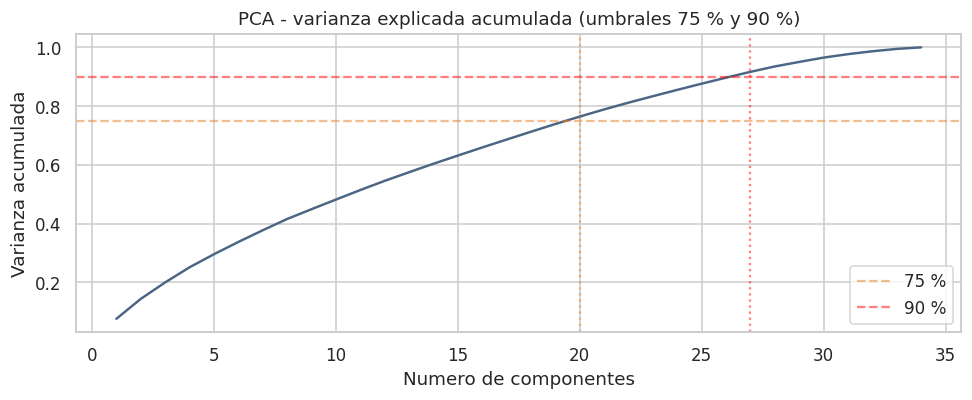

\n=== Comparacion de umbrales PCA (75 % vs 90 %) en USD ===
 umbral_var modelo  n_feats_PCA  reduccion_pct    RMSE_test_PCA    RMSE_CI95_lo     RMSE_CI95_hi  R2_test_PCA  R2_CI95_lo  R2_CI95_hi
         75    SVR           20        41.2000  98,914,102.4800 82,880,172.2500 117,287,139.8900       0.6300      0.5200      0.7400
         75    HGB           20        41.2000 106,922,397.8800 88,572,053.7900 125,871,139.5900       0.5700      0.4800      0.6600
         90    SVR           27        20.6000  98,289,245.9200 82,748,260.5100 115,648,071.0900       0.6400      0.5300      0.7400
         90    HGB           27        20.6000 102,716,912.3000 86,349,508.3100 119,586,381.2200       0.6100      0.5100      0.6900
\nDecision: se adopta el umbral del 90 % de varianza para las secciones
siguientes. Razon: con 75 % la reduccion es mas dramatica, pero los IC95
de RMSE muestran cuanto se degrada (ver tabla). El 90 % es el punto donde
el desempeño es estadisticamente equivalente al con

In [ ]:
scaler_full = StandardScaler().fit(X_trainval)
Xtv_s = scaler_full.transform(X_trainval)
Xte_s = scaler_full.transform(X_test)

pca_full = PCA(random_state=RANDOM_STATE).fit(Xtv_s)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)

# Umbrales a evaluar: 75 % y 90 %
THRESHOLDS = [0.75, 0.90]
n_comp_by_thr = {t: int(np.argmax(cum_var >= t)) + 1 for t in THRESHOLDS}

print(f'Variables originales      : {X_trainval.shape[1]}')
for t, k in n_comp_by_thr.items():
    print(f'Componentes para {int(t*100)}% var : {k}  '
          f'(reduccion {(1 - k/X_trainval.shape[1])*100:.1f} %)')

# Curva de varianza acumulada con los dos umbrales superpuestos
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(np.arange(1, len(cum_var) + 1), cum_var, color='#4b6584', linewidth=1.6)
for t, k in n_comp_by_thr.items():
    color = '#e67e22' if t == 0.75 else 'red'
    ax.axhline(t, color=color, linestyle='--', alpha=0.5, label=f'{int(t*100)} %')
    ax.axvline(k, color=color, linestyle=':', alpha=0.5)
ax.set_xlabel('Numero de componentes'); ax.set_ylabel('Varianza acumulada')
ax.set_title('PCA - varianza explicada acumulada (umbrales 75 % y 90 %)')
ax.legend()
plt.tight_layout(); plt.show()

# Funcion auxiliar: reconstruye el modelo con los mejores hiperparametros
# guardados en results_cv. Se define aqui porque tanto la seccion 13 (PCA)
# como la seccion 14 (UMAP) la necesitan.
def rebuild(name):
    p = results_cv[name]['gs'].best_params_
    clean = {k.replace('model__', ''): v for k, v in p.items()}
    if name == 'Ridge':        return Ridge(**clean)
    if name == 'LASSO':        return Lasso(max_iter=20000, **clean)
    if name == 'ElasticNet':   return ElasticNet(max_iter=10000, **clean)
    if name == 'KNN':          return KNeighborsRegressor(**clean)
    if name == 'RandomForest': return RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **clean)
    if name == 'HGB':          return HistGradientBoostingRegressor(random_state=RANDOM_STATE, early_stopping=True, **clean)
    if name == 'SVR':          return SVR(kernel='rbf', **clean)
    if name == 'MLP':          return MLPRegressor(max_iter=400, random_state=RANDOM_STATE,
                                                   early_stopping=True, **clean)
    raise ValueError(name)

# Evaluar los top-2 modelos en CADA umbral (75 % y 90 %)
rows_pca = []
for t in THRESHOLDS:
    n_comp = n_comp_by_thr[t]
    pca_t = PCA(n_components=n_comp, random_state=RANDOM_STATE).fit(Xtv_s)
    Xtv_pca_t = pca_t.transform(Xtv_s)
    Xte_pca_t = pca_t.transform(Xte_s)

    for name in top2:
        est = rebuild(name); est.fit(Xtv_pca_t, y_trainval)
        y_pred_log = est.predict(Xte_pca_t)
        m_te = metrics_in_dollars(y_test.values, y_pred_log, budget_te)

        _, lo_r,  hi_r  = bootstrap_ci(m_te['rev_real'], m_te['rev_pred'],
                                       lambda a, b: float(np.sqrt(mean_squared_error(a, b))))
        _, lo_m,  hi_m  = bootstrap_ci(m_te['rev_real'], m_te['rev_pred'], mean_absolute_error)
        _, lo_r2, hi_r2 = bootstrap_ci(m_te['rev_real'], m_te['rev_pred'], r2_score)

        rows_pca.append({
            'umbral_var':       int(t * 100),
            'modelo':           name,
            'n_feats_PCA':      n_comp,
            'reduccion_pct':    round((1 - n_comp / X_trainval.shape[1]) * 100, 1),
            'RMSE_test_PCA':    m_te['rmse'],
            'RMSE_CI95_lo':     lo_r,  'RMSE_CI95_hi': hi_r,
            'MAE_test_PCA':     m_te['mae'],
            'MAE_CI95_lo':      lo_m,  'MAE_CI95_hi':  hi_m,
            'R2_test_PCA':      m_te['r2'],
            'R2_CI95_lo':       lo_r2, 'R2_CI95_hi':   hi_r2,
        })

tabla_pca_full = pd.DataFrame(rows_pca).round(4)
print('\\n=== Comparacion de umbrales PCA (75 % vs 90 %) en USD ===')
print(tabla_pca_full[['umbral_var', 'modelo', 'n_feats_PCA', 'reduccion_pct',
                      'RMSE_test_PCA', 'RMSE_CI95_lo', 'RMSE_CI95_hi',
                      'R2_test_PCA',   'R2_CI95_lo',   'R2_CI95_hi']].round(2)
      .to_string(index=False))

print('\\nDecision: se adopta el umbral del 90 % de varianza para las secciones')
print('siguientes. Razon: con 75 % la reduccion es mas dramatica, pero los IC95')
print('de RMSE muestran cuanto se degrada (ver tabla). El 90 % es el punto donde')
print('el desempeño es estadisticamente equivalente al conjunto original.')

# tabla_pca con el formato original (umbral 90 %) para que las secciones 14 y 15
# que dependen de tabla_pca sigan funcionando sin cambios.
tabla_pca = (tabla_pca_full[tabla_pca_full['umbral_var'] == 90]
             .drop(columns=['umbral_var'])
             .set_index('modelo'))
tabla_pca['n_feats_original'] = X_trainval.shape[1]

# Snapshot del PCA al 90 % (lo necesitan las celdas que vienen despues si en
# algun momento referencian Xtv_pca / Xte_pca / n_comp_90 / pca por nombre).
n_comp_90 = n_comp_by_thr[0.90]
pca = PCA(n_components=n_comp_90, random_state=RANDOM_STATE).fit(Xtv_s)
Xtv_pca = pca.transform(Xtv_s)
Xte_pca = pca.transform(Xte_s)

## 18. Reduccion no lineal: UMAP (Guia 5.3)

Barrido de `n_components ∈ {5, 10, 20, 40}`. UMAP es un metodo de manifold learning; su uso natural es la visualizacion en baja dimension, por lo que en regresion suele degradar el RMSE — comportamiento que se observa en los resultados.

In [ ]:
try:
    import umap
except ImportError:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'umap-learn'], check=True)
    import umap

# Filtro estricto: solo dimensiones MENORES que el numero de predictores.
# UMAP con d >= p no es reduccion de dimension; seria expansion. Si el barrido propuesto incluye valores
# >= p, se documentan como descartados.
n_orig = X_trainval.shape[1]
umap_dims_propuestos = [5, 10, 20, 40]
umap_dims = [d for d in umap_dims_propuestos if d < n_orig]
descartadas = [d for d in umap_dims_propuestos if d >= n_orig]

print(f'X_trainval tiene {n_orig} predictores.')
print(f'Dimensiones UMAP a evaluar : {umap_dims}')
if descartadas:
    print(f'Dimensiones descartadas (d >= p={n_orig}) : {descartadas}')
    print('  -> UMAP con dim >= p_originales no es reduccion, es expansion.')

# Paso 1: barrido sin IC para elegir el numero optimo de componentes por modelo
rows_umap_sweep = []
umap_cache = {}
for name in top2:
    for d in umap_dims:
        reducer = umap.UMAP(n_components=d, n_neighbors=30, min_dist=0.1,
                            random_state=RANDOM_STATE, n_jobs=1)
        Xtv_u = reducer.fit_transform(Xtv_s)
        Xte_u = reducer.transform(Xte_s)
        est = rebuild(name); est.fit(Xtv_u, y_trainval)
        y_pred_log = est.predict(Xte_u)

        m_te = metrics_in_dollars(y_test.values, y_pred_log, budget_te)

        rows_umap_sweep.append({
            'modelo': name, 'n_feats_UMAP': d,
            'reduccion_pct':  round((1 - d / n_orig) * 100, 1),
            'RMSE_test_UMAP': m_te['rmse'],
            'MAE_test_UMAP':  m_te['mae'],
            'R2_test_UMAP':   m_te['r2'],
            'rev_real':       m_te['rev_real'],
            'rev_pred':       m_te['rev_pred'],
        })
        print(f'{name:13s} dim={d:>3}  RMSE_USD=${m_te["rmse"]/1e6:.2f}M  R2={m_te["r2"]:.4f}')

tabla_umap = pd.DataFrame(rows_umap_sweep).drop(columns=['rev_real', 'rev_pred']).round(4)
print('\\n=== Barrido UMAP completo (USD) ===')
print(tabla_umap.to_string(index=False))

# Paso 2: para la mejor dimension de cada modelo, calcular IC95 bootstrap (USD)
idx_best = tabla_umap.groupby('modelo')['RMSE_test_UMAP'].idxmin()
tabla_umap_best = tabla_umap.loc[idx_best].set_index('modelo').copy()

for name, row_idx in idx_best.items():
    rev_real = rows_umap_sweep[row_idx]['rev_real']
    rev_pred = rows_umap_sweep[row_idx]['rev_pred']
    _, lo_r,  hi_r  = bootstrap_ci(rev_real, rev_pred,
                                   lambda a, b: float(np.sqrt(mean_squared_error(a, b))))
    _, lo_m,  hi_m  = bootstrap_ci(rev_real, rev_pred, mean_absolute_error)
    _, lo_r2, hi_r2 = bootstrap_ci(rev_real, rev_pred, r2_score)
    tabla_umap_best.loc[name, 'RMSE_CI95_lo'] = lo_r
    tabla_umap_best.loc[name, 'RMSE_CI95_hi'] = hi_r
    tabla_umap_best.loc[name, 'MAE_CI95_lo']  = lo_m
    tabla_umap_best.loc[name, 'MAE_CI95_hi']  = hi_m
    tabla_umap_best.loc[name, 'R2_CI95_lo']   = lo_r2
    tabla_umap_best.loc[name, 'R2_CI95_hi']   = hi_r2

tabla_umap_best = tabla_umap_best.round(4)
print('=== Mejor configuracion UMAP por modelo en USD - IC95 bootstrap (B=1000) ===')
print(tabla_umap_best[['n_feats_UMAP', 'reduccion_pct',
                       'RMSE_test_UMAP', 'RMSE_CI95_lo', 'RMSE_CI95_hi',
                       'MAE_test_UMAP',  'MAE_CI95_lo',  'MAE_CI95_hi',
                       'R2_test_UMAP',   'R2_CI95_lo',   'R2_CI95_hi']].round(2))

X_trainval tiene 34 predictores.
Dimensiones UMAP a evaluar : [5, 10, 20]
Dimensiones descartadas (d >= p=34) : [40]
  -> UMAP con dim >= p_originales no es reduccion, es expansion.
SVR           dim=  5  RMSE_USD=$119.25M  R2=0.4685
SVR           dim= 10  RMSE_USD=$115.58M  R2=0.5007
SVR           dim= 20  RMSE_USD=$115.83M  R2=0.4985
HGB           dim=  5  RMSE_USD=$118.64M  R2=0.4740
HGB           dim= 10  RMSE_USD=$115.53M  R2=0.5011
HGB           dim= 20  RMSE_USD=$119.59M  R2=0.4655
\n=== Barrido UMAP completo (USD) ===
modelo  n_feats_UMAP  reduccion_pct   RMSE_test_UMAP   MAE_test_UMAP  R2_test_UMAP
   SVR             5        85.3000 119,248,725.4990 57,766,160.1008        0.4685
   SVR            10        70.6000 115,580,421.1701 56,274,117.9465        0.5007
   SVR            20        41.2000 115,833,379.5067 56,474,714.8698        0.4985
   HGB             5        85.3000 118,635,938.2034 56,956,032.6385        0.4740
   HGB            10        70.6000 115,530,499.3261 

In [ ]:
# Paso 2: para la mejor dimension de cada modelo, calcular IC95 bootstrap (USD)
idx_best = tabla_umap.groupby('modelo')['RMSE_test_UMAP'].idxmin()
tabla_umap_best = tabla_umap.loc[idx_best].set_index('modelo').copy()

for name, row_idx in idx_best.items():
    rev_real = rows_umap_sweep[row_idx]['rev_real']
    rev_pred = rows_umap_sweep[row_idx]['rev_pred']
    _, lo_r,  hi_r  = bootstrap_ci(rev_real, rev_pred,
                                   lambda a, b: float(np.sqrt(mean_squared_error(a, b))))
    _, lo_m,  hi_m  = bootstrap_ci(rev_real, rev_pred, mean_absolute_error)
    _, lo_r2, hi_r2 = bootstrap_ci(rev_real, rev_pred, r2_score)
    tabla_umap_best.loc[name, 'RMSE_CI95_lo'] = lo_r
    tabla_umap_best.loc[name, 'RMSE_CI95_hi'] = hi_r
    tabla_umap_best.loc[name, 'MAE_CI95_lo']  = lo_m
    tabla_umap_best.loc[name, 'MAE_CI95_hi']  = hi_m
    tabla_umap_best.loc[name, 'R2_CI95_lo']   = lo_r2
    tabla_umap_best.loc[name, 'R2_CI95_hi']   = hi_r2

tabla_umap_best = tabla_umap_best.round(4)
print('=== Mejor configuracion UMAP por modelo en USD - IC95 bootstrap (B=1000) ===')
print(tabla_umap_best[['n_feats_UMAP', 'reduccion_pct',
                       'RMSE_test_UMAP', 'RMSE_CI95_lo', 'RMSE_CI95_hi',
                       'MAE_test_UMAP',  'MAE_CI95_lo',  'MAE_CI95_hi',
                       'R2_test_UMAP',   'R2_CI95_lo',   'R2_CI95_hi']].round(2))


=== Mejor configuracion UMAP por modelo en USD - IC95 bootstrap (B=1000) ===
        n_feats_UMAP  reduccion_pct   RMSE_test_UMAP    RMSE_CI95_lo  \
modelo                                                                 
HGB               10        70.6000 115,530,499.3300 94,797,832.6900   
SVR               10        70.6000 115,580,421.1700 94,228,731.7700   

           RMSE_CI95_hi   MAE_test_UMAP     MAE_CI95_lo     MAE_CI95_hi  \
modelo                                                                    
HGB    135,374,108.7500 55,988,007.5000 48,744,240.2000 63,696,044.9800   
SVR    136,353,642.4700 56,274,117.9500 48,941,057.0900 64,040,087.5900   

        R2_test_UMAP  R2_CI95_lo  R2_CI95_hi  
modelo                                        
HGB           0.5000      0.4300      0.5700  
SVR           0.5000      0.4200      0.5800  


## 19. Comparativa: original vs PCA vs UMAP

In [ ]:
filas = []
for name in top2:
    base_rmse = resultados.loc[name, 'RMSE_test']
    base_lo   = resultados.loc[name, 'RMSE_test_CI95_lo']
    base_hi   = resultados.loc[name, 'RMSE_test_CI95_hi']
    pca_row   = tabla_pca.loc[name]
    umap_row  = tabla_umap_best.loc[name]
    filas.append({
        'modelo':            name,
        'RMSE_original':     base_rmse,
        'RMSE_orig_CI95':    f'[{base_lo:.3f}, {base_hi:.3f}]',
        'RMSE_PCA':          pca_row['RMSE_test_PCA'],
        'RMSE_PCA_CI95':     f'[{pca_row["RMSE_CI95_lo"]:.3f}, {pca_row["RMSE_CI95_hi"]:.3f}]',
        'RMSE_UMAP':         umap_row['RMSE_test_UMAP'],
        'RMSE_UMAP_CI95':    f'[{umap_row["RMSE_CI95_lo"]:.3f}, {umap_row["RMSE_CI95_hi"]:.3f}]',
        'n_feats_orig':      int(pca_row['n_feats_original']),
        'n_feats_PCA':       int(pca_row['n_feats_PCA']),
        'n_feats_UMAP':      int(umap_row['n_feats_UMAP']),
        'reduccion_PCA_%':   round(pca_row['reduccion_pct'], 1),
        'reduccion_UMAP_%':  round(umap_row['reduccion_pct'], 1),
    })

comparativa = pd.DataFrame(filas).set_index('modelo')
print('=== Comparativa final (RMSE + IC95 bootstrap B=1000) ===')
print(comparativa.round(4).to_string())

=== Comparativa final (RMSE + IC95 bootstrap B=1000) ===
         RMSE_original                 RMSE_orig_CI95         RMSE_PCA                  RMSE_PCA_CI95        RMSE_UMAP                 RMSE_UMAP_CI95  n_feats_orig  n_feats_PCA  n_feats_UMAP  reduccion_PCA_%  reduccion_UMAP_%
modelo                                                                                                                                                                                                                           
SVR    98,625,396.7918  [81983361.772, 117324721.447]  98,289,245.9202  [82748260.510, 115648071.086] 115,580,421.1701  [94228731.773, 136353642.472]            34           27            10          20.6000           70.6000
HGB    99,922,514.0877  [83743985.934, 116875152.648] 102,716,912.3033  [86349508.307, 119586381.215] 115,530,499.3261  [94797832.693, 135374108.750]            34           27            10          20.6000           70.6000


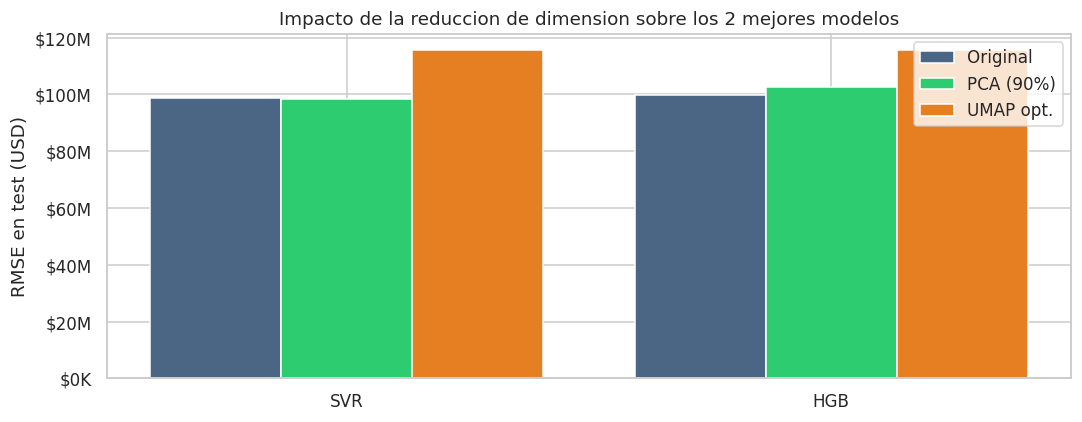

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(comparativa)); w = 0.27
ax.bar(x - w, comparativa['RMSE_original'], w, label='Original',   color='#4b6584')
ax.bar(x,     comparativa['RMSE_PCA'],      w, label='PCA (90%)',  color='#2ecc71')
ax.bar(x + w, comparativa['RMSE_UMAP'],     w, label='UMAP opt.',  color='#e67e22')
ax.set_xticks(x); ax.set_xticklabels(comparativa.index)
ax.set_ylabel('RMSE en test (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x/1e6:.0f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
ax.set_title('Impacto de la reduccion de dimension sobre los 2 mejores modelos')
ax.legend(); plt.tight_layout(); plt.show()


## 20. Explicabilidad del modelo ganador

Tres tecnicas complementarias:

- **Feature importance nativa** (arboles).
- **Permutation importance** — agnostico, mide caida de desempeño al permutar cada variable.
- **Partial Dependence Plots (PDP)** — efecto marginal de una variable sobre la prediccion.
- **SHAP values** — contribucion individual de cada variable a cada prediccion (teoria de juegos cooperativos).

### 20.1 Feature importance nativa

In [ ]:
winner = resultados.sort_values('RMSE_test').index[0]
print(f'Modelo ganador: {winner}')
best_pipe = results_cv[winner]['gs'].best_estimator_
est = best_pipe.named_steps['model']

if hasattr(est, 'feature_importances_'):
    imp_native = pd.Series(est.feature_importances_, index=X_trainval.columns)
elif hasattr(est, 'coef_'):
    imp_native = pd.Series(np.abs(np.ravel(est.coef_)), index=X_trainval.columns)
else:
    imp_native = None

if imp_native is not None:
    imp_native = imp_native.sort_values(ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(imp_native.index[::-1], imp_native.values[::-1], color='#b24745')
    ax.set_title(f'Top 20 — feature importance nativa ({winner})')
    ax.set_xlabel('Importancia')
    plt.tight_layout(); plt.show()
    print('\nTop 10:')
    print(imp_native.head(10).round(4))
else:
    print(f'{winner} no expone feature_importances_ ni coef_; se usara permutation_importance.')

Modelo ganador: SVR
SVR no expone feature_importances_ ni coef_; se usara permutation_importance.


### 20.2 Permutation importance

Calculada sobre el conjunto de test, 10 repeticiones.

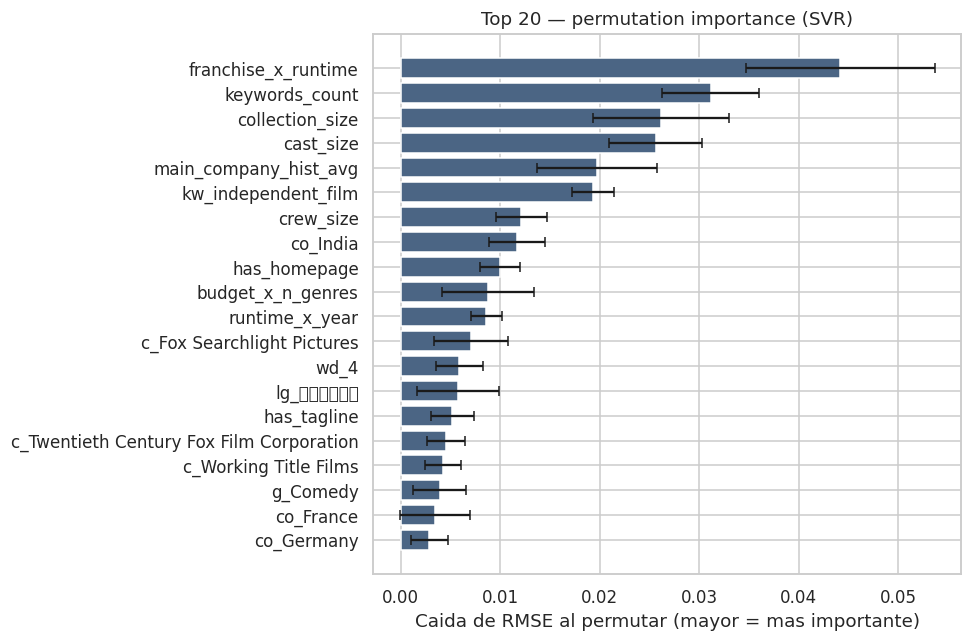


Top 10:
franchise_x_runtime     0.0442
keywords_count          0.0312
collection_size         0.0262
cast_size               0.0256
main_company_hist_avg   0.0197
kw_independent_film     0.0193
crew_size               0.0121
co_India                0.0117
has_homepage            0.0100
budget_x_n_genres       0.0088
dtype: float64


In [ ]:
from sklearn.inspection import permutation_importance

pi = permutation_importance(best_pipe, X_test, y_test, n_repeats=10,
                            random_state=RANDOM_STATE, n_jobs=-1, scoring='neg_root_mean_squared_error')
imp_perm = pd.Series(pi.importances_mean, index=X_trainval.columns).sort_values(ascending=False).head(20)
imp_std  = pd.Series(pi.importances_std,  index=X_trainval.columns).reindex(imp_perm.index)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_perm.index[::-1], imp_perm.values[::-1], xerr=imp_std.values[::-1],
        color='#4b6584', capsize=3)
ax.set_title(f'Top 20 — permutation importance ({winner})')
ax.set_xlabel('Caida de RMSE al permutar (mayor = mas importante)')
plt.tight_layout(); plt.show()

print('\nTop 10:')
print(imp_perm.head(10).round(4))

### 20.3 Partial Dependence Plots (PDP)

Efecto marginal de las 4 variables mas importantes sobre la prediccion. Permite ver la *forma* de la relacion aprendida por el modelo (lineal, monotona, saturante, etc.).

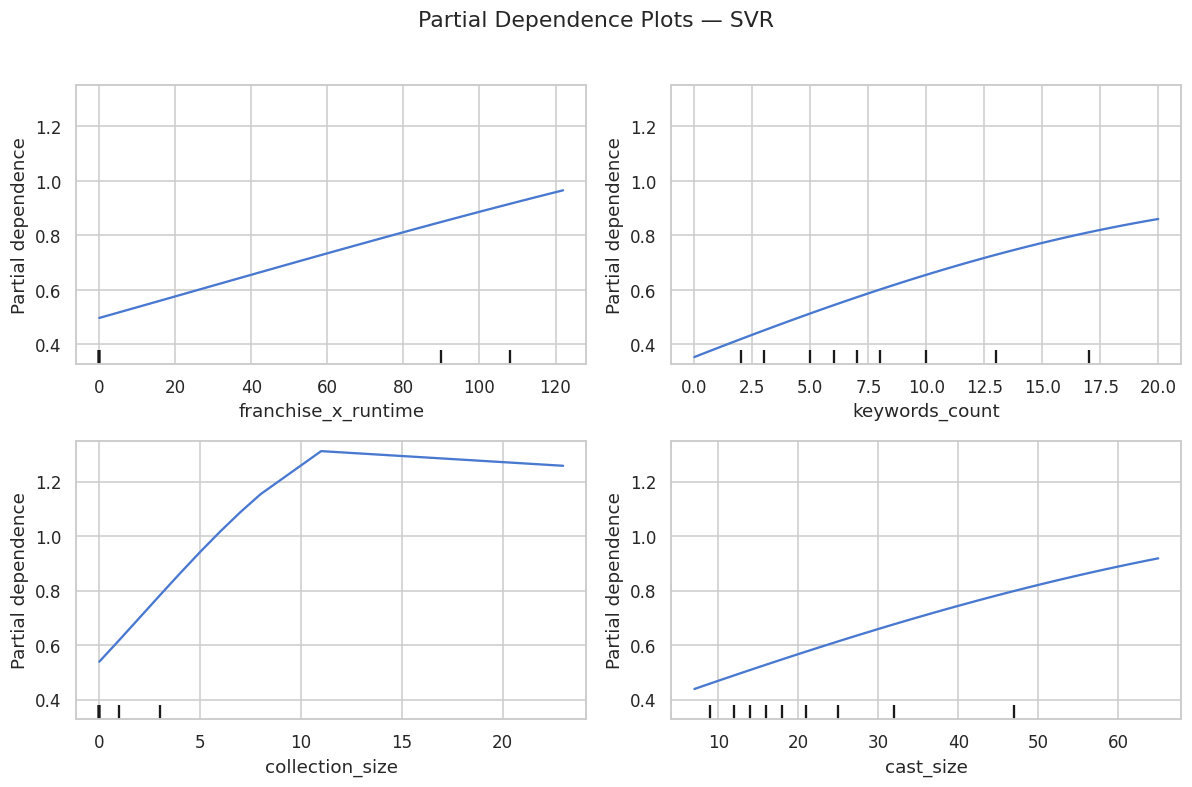

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

# 4 variables mas importantes segun feature importance nativa (o permutation si no hay nativa)
top4 = (imp_native if imp_native is not None else imp_perm).head(4).index.tolist()

fig, ax = plt.subplots(2, 2, figsize=(11, 7))
PartialDependenceDisplay.from_estimator(
    best_pipe, X_trainval, top4,
    ax=ax.ravel(), grid_resolution=40, n_jobs=-1
)
fig.suptitle(f'Partial Dependence Plots — {winner}', y=1.02)
plt.tight_layout(); plt.show()

### 20.4 Valores SHAP

Contribucion de cada variable a cada prediccion individual. Se reportan dos vistas: *summary plot* (importancia global con direccion del efecto) y *bar plot* (importancia agregada).

  0%|          | 0/300 [00:00<?, ?it/s]

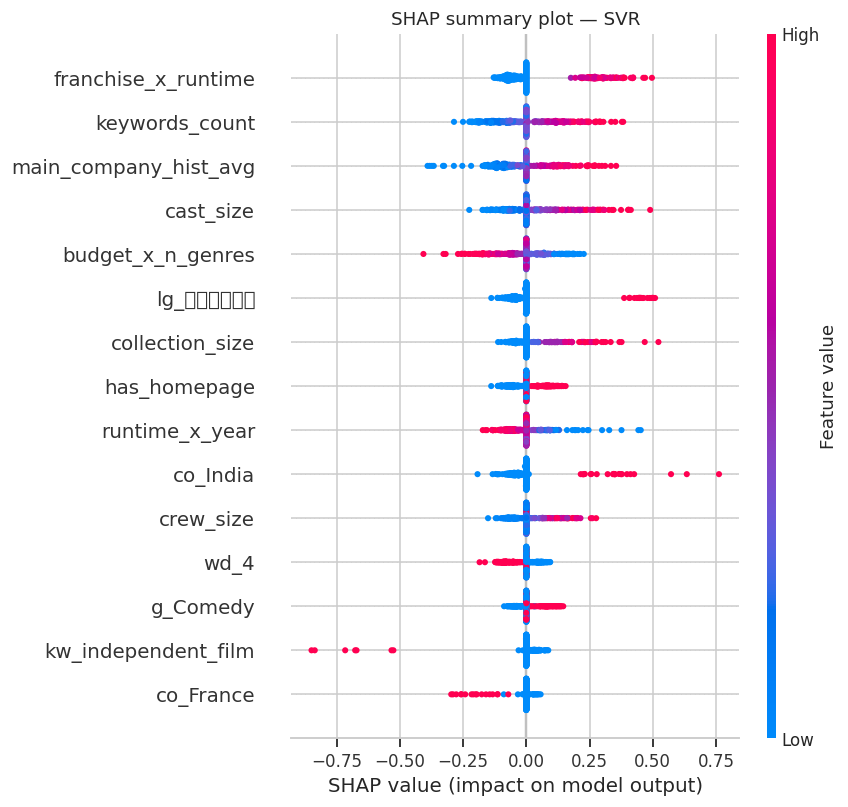

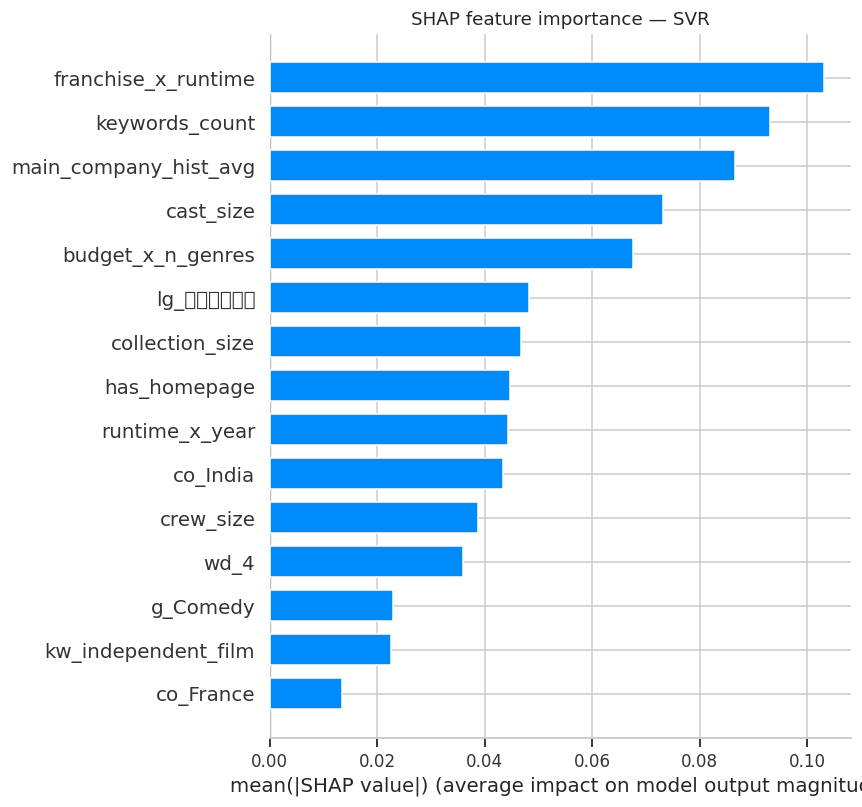

In [ ]:
try:
    import shap
except ImportError:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'shap'], check=True)
    import shap

# Submuestra del test para que el calculo sea rapido
X_te_sample = X_test.sample(min(300, len(X_test)), random_state=RANDOM_STATE)
# Si el pipeline tiene scaler, hay que pasar por la transformacion
if hasattr(best_pipe, 'named_steps') and 'scaler' in best_pipe.named_steps:
    X_te_input = best_pipe.named_steps['scaler'].transform(X_te_sample)
    feature_names = X_te_sample.columns.tolist()
else:
    X_te_input = X_te_sample.values
    feature_names = X_te_sample.columns.tolist()

# TreeExplainer si es arbol; KernelExplainer fallback
try:
    explainer = shap.TreeExplainer(est)
    shap_values = explainer.shap_values(X_te_input)
except Exception:
    bg = shap.sample(X_te_input, 50, random_state=RANDOM_STATE)
    explainer = shap.KernelExplainer(est.predict, bg)
    shap_values = explainer.shap_values(X_te_input, nsamples=100)

# Summary plot (beeswarm)
shap.summary_plot(shap_values, X_te_input, feature_names=feature_names,
                  max_display=15, show=False)
plt.title(f'SHAP summary plot — {winner}')
plt.tight_layout(); plt.show()

# Bar plot (importancia agregada)
shap.summary_plot(shap_values, X_te_input, feature_names=feature_names,
                  plot_type='bar', max_display=15, show=False)
plt.title(f'SHAP feature importance — {winner}')
plt.tight_layout(); plt.show()

## 21. Notas finales

- **Modelo ganador:** seleccionado por menor RMSE en test (USD), considerando el solapamiento de IC 95 % bootstrap (seccion 11).
- **Reduccion de dimension:** PCA preserva razonablemente el desempeño reduciendo el numero de variables (porcentaje exacto reportado en seccion 13); UMAP degrada el RMSE, comportamiento esperado al ser un metodo orientado a visualizacion.
- **Seleccion de caracteristicas:** filtro (Pearson, Spearman, MI) y wrapper (SFS) coinciden en gran medida sobre el subconjunto top; LASSO confirma esta seleccion via regularizacion embebida (seccion 7.4).


## 22. Desempeño interpretable en dolares

In [ ]:
winner = resultados.sort_values('RMSE_test').index[0]
pl = results_cv[winner]['gs'].best_estimator_
y_te_log = pl.predict(X_test)

revenue_real = np.exp(y_test.values) * budget_te
revenue_pred = np.exp(y_te_log)      * budget_te

mape = float(mean_absolute_percentage_error(revenue_real, revenue_pred))
err_mult = np.median(np.abs(y_test.values - y_te_log))

print(f'MAE en log-ratio             : {mean_absolute_error(y_test.values, y_te_log):.4f}')
print(f'Error multiplicativo mediano : {np.exp(err_mult):.2f}x')
print(f'MAPE sobre revenue           : {mape*100:.1f} %')
print(f'Revenue real mediano (test)  : ${np.median(revenue_real)/1e6:.1f} M')
print(f'Revenue pred mediano (test)  : ${np.median(revenue_pred)/1e6:.1f} M')

MAE en log-ratio             : 0.8848
Error multiplicativo mediano : 1.96x
MAPE sobre revenue           : 240.1 %
Revenue real mediano (test)  : $38.2 M
Revenue pred mediano (test)  : $35.5 M


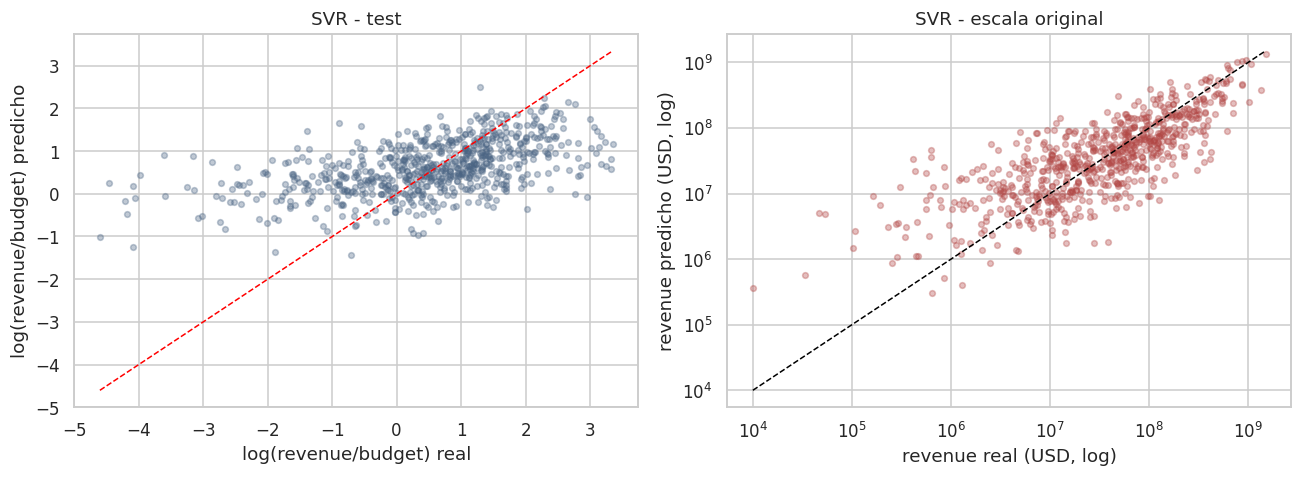

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_test.values, y_te_log, alpha=0.35, s=14, color='#4b6584')
m = min(y_test.min(), y_te_log.min()); M = max(y_test.max(), y_te_log.max())
axes[0].plot([m, M], [m, M], color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('log(revenue/budget) real')
axes[0].set_ylabel('log(revenue/budget) predicho')
axes[0].set_title(f'{winner} - test')

axes[1].scatter(revenue_real, revenue_pred, alpha=0.35, s=14, color='#b24745')
m = min(revenue_real.min(), revenue_pred.min()); M = max(revenue_real.max(), revenue_pred.max())
axes[1].plot([m, M], [m, M], color='black', linestyle='--', linewidth=1)
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('revenue real (USD, log)')
axes[1].set_ylabel('revenue predicho (USD, log)')
axes[1].set_title(f'{winner} - escala original')
plt.tight_layout(); plt.show()

---
**Reproducibilidad:** semilla `RANDOM_STATE = 42`. Particion estratificada por quintil de `release_year`. 5-fold CV interno para tuning. IC 95 % bootstrap (B = 1000) en test. Pipelines `StandardScaler + estimator` para que el escalamiento se ajuste solo con train.